# PCLab#4 - Group 4 - Claas Boumans Giuliano Ciaramella Theodor Nissen-Meyer

**20598 – Finance with Big Data · PC Lab #4: Predicting Stock Returns with ML**

*Time required: approximately 12 hours. Difficulty: 7 out of 10. (excl. optional tasks)*

## 0. Setup
Libraries and the chart theme of the previous labs; constants and helpers are defined where they are first needed. With the forecasts cached in 3.2 and 3.5 the notebook runs in about a minute, without them in about 23.

In [1]:
import os
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.base import clone
from sklearn.linear_model import BayesianRidge, ElasticNet, LinearRegression, Ridge
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
try:                                                                # only needed to retrain the models of Task #3:
    import lightgbm as lgb                                          # their cached forecasts load without them (3.2)
    import torch
    from torch import nn
except ImportError:
    lgb = torch = nn = None

pd.set_option("display.float_format", "{:,.4f}".format)
warnings.filterwarnings("ignore", category=FutureWarning)           # pandas' notice on its new stack() implementation

In [2]:
# Chart theme inspired by The Economist: white background, horizontal gridlines,
# bold left-aligned titles, red rule on top, the magazine's blue/teal palette.
ECONOMIST_RED = "#E3120B"
ECONOMIST_COLORS = ["#006BA2", "#3EBCD2", "#379A8B", "#EBB434", "#B4BA39",
                    "#9A607F", "#D1B07C", "#758D99", "#DB444B"]

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=ECONOMIST_COLORS),
    "axes.grid": True,
    "axes.grid.axis": "y",              # horizontal gridlines only
    "grid.color": "#D0D0D0",
    "axes.axisbelow": True,             # gridlines behind the data
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "ytick.left": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "legend.frameon": False,
    "lines.linewidth": 1.6,
})

ECONOMIST_BLUES = LinearSegmentedColormap.from_list("economist_blues", ["#C5E4F0", "#3EBCD2", "#006BA2", "#0C2A4A"])
GREY, LIGHT_GREY = "#758D99", "#C9D3D9"


def show():
    '''Add the red rule and tag on top of the current figure, then display it.'''
    fig = plt.gcf()
    fig.tight_layout()
    fig.add_artist(plt.Line2D([0, 1], [1.02, 1.02], transform=fig.transFigure, color=ECONOMIST_RED, lw=1.5))
    fig.add_artist(plt.Rectangle((0, 1.02), 0.035, 0.015, transform=fig.transFigure, color=ECONOMIST_RED, clip_on=False))
    plt.show()

## Task #1 – Basic manipulation and descriptive statistics
Task #1 uses only the lab files: daily closing prices and volumes (in shares) of eight stocks and the S&P 500, January 2012 to August 2020. We skip the optional description of the sample.

In [3]:
LAB_PRICES, LAB_VOLUMES = "Data_PCLab4_Stock_Price.csv", "Data_PCLab4_Stock_Volume.csv"


def load_lab(path):
    '''One lab file: a column per security, indexed by date.'''
    return pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").set_index("Date")


prices, volumes = load_lab(LAB_PRICES), load_lab(LAB_VOLUMES)
stocks = list(prices.columns.drop("sp500"))

print(f"Sample: {prices.index[0].date()} to {prices.index[-1].date()} ({len(prices):,} trading days), securities: {list(prices.columns)}")
print("Same days and columns in both files:", prices.index.equals(volumes.index) and prices.columns.equals(volumes.columns),
      "| missing values:", int(prices.isna().sum().sum() + volumes.isna().sum().sum()), "| days with zero volume:", int((volumes == 0).sum().sum()))

Sample: 2012-01-12 to 2020-08-11 (2,159 trading days), securities: ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG', 'sp500']
Same days and columns in both files: True | missing values: 0 | days with zero volume: 0


### 1.1 Volumes over time, raw and normalised
Daily volumes are noisy, so we plot 20-day averages: in shares on a log scale (raw) and relative to each security's average day (normalised, 1 = an average day). The dashed line marks the start of the COVID-19 pandemic.

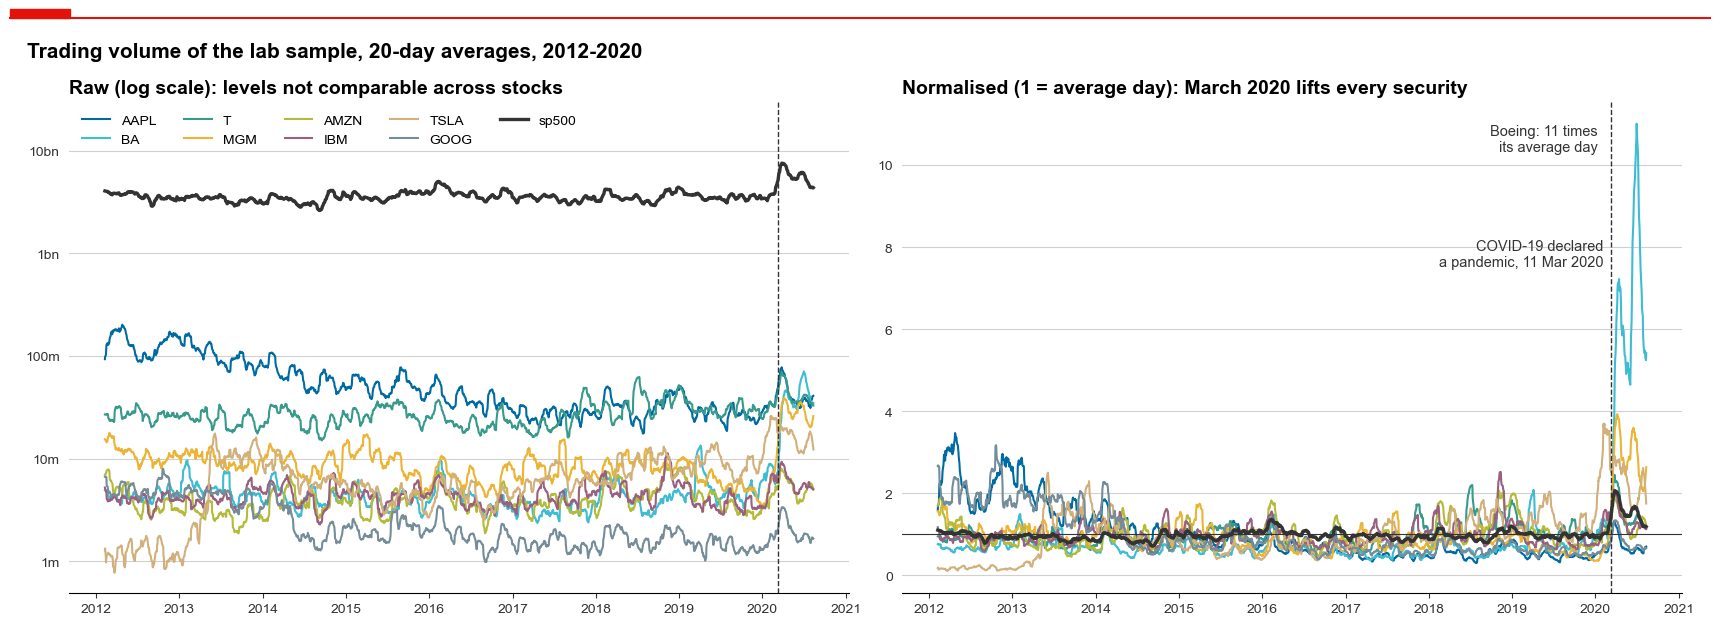

March 2020, times the average day: BA 5.3, MGM 3.5, TSLA 2.7, T 2.3, sp500 2.0, IBM 1.9, AMZN 1.8, GOOG 1.3, AAPL 1.2


In [4]:
def millions(value, _):
    '''Axis label in millions or billions of shares.'''
    return f"{value / 1e9:g}bn" if value >= 1e9 else f"{value / 1e6:g}m"


PANDEMIC = pd.Timestamp("2020-03-11")                                   # the WHO declares COVID-19 a pandemic


def plot_volumes(volumes):
    '''20-day average volume of every security, in shares (log scale) and relative to its own average day.'''
    smooth = volumes.rolling(20).mean().dropna()
    normalised = smooth / volumes.mean()
    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    for color, column in zip(ECONOMIST_COLORS, smooth.columns):
        style = {"color": "#333333", "lw": 2.4} if column == "sp500" else {"color": color, "lw": 1.5}
        axes[0].plot(smooth.index, smooth[column], label=column, **style)
        axes[1].plot(normalised.index, normalised[column], **style)

    axes[0].set_yscale("log")
    axes[0].yaxis.set_major_formatter(FuncFormatter(millions))
    axes[0].set_ylim(top=smooth.values.max() * 4)                                     # room for the legend
    axes[0].set_title("Raw (log scale): levels not comparable across stocks")
    axes[0].legend(loc="upper left", ncol=5, fontsize=10)
    axes[1].axhline(1, color="#333333", lw=0.8)
    axes[1].set_title("Normalised (1 = average day): March 2020 lifts every security")
    axes[1].annotate(f"Boeing: {normalised['BA'].max():.0f} times\nits average day", (normalised["BA"].idxmax(), normalised["BA"].max()),
                     xytext=(-28, 0), textcoords="offset points", ha="right", va="top", fontsize=10.5, color="#333333")
    axes[1].annotate("COVID-19 declared\na pandemic, 11 Mar 2020", (PANDEMIC, 0.72), xycoords=("data", "axes fraction"), xytext=(-6, 0),
                     textcoords="offset points", ha="right", va="top", fontsize=10.5, color="#333333")
    for ax in axes:
        ax.axvline(PANDEMIC, color="#333333", lw=1, ls="--")
        ax.grid(False, axis="x")
    fig.suptitle("Trading volume of the lab sample, 20-day averages, 2012-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_volumes(volumes)
march = (volumes.loc["2020-03"].mean() / volumes.mean()).sort_values(ascending=False)
print("March 2020, times the average day:", ", ".join(f"{name} {value:.1f}" for name, value in march.items()))

**Comments – 1.1**

- **Raw volumes are not comparable** (left): share volumes differ by more than an order of magnitude across the stocks and drift with the share price; Apple's and Alphabet's fall as their prices rise.
- **March 2020 lifts every security** (right, dashed line): all trade above their average day, the S&P 500 at 2.0 times, the stocks at 1.2 (Apple) to 5.3 times (Boeing). Stock-specific news drives the extremes, such as Boeing at 11 times its average day in June 2020, after the 737 MAX groundings and the collapse of air travel.
- **Hence the volume signals of Task #2 compare a stock's recent volume with its own past year.**

### 1.2 Do returns and volumes move together?
We correlate the daily change in log volume $\Delta \ln V_t$ with the daily return $r_t$ (does volume rise when prices rise?), the absolute return (when prices move?) and the next day's return (does volume predict?). The point clouds pool the eight stocks, one point per stock-day (days beyond the axes are left out); the line averages the points in each bin with at least 100 stock-days.

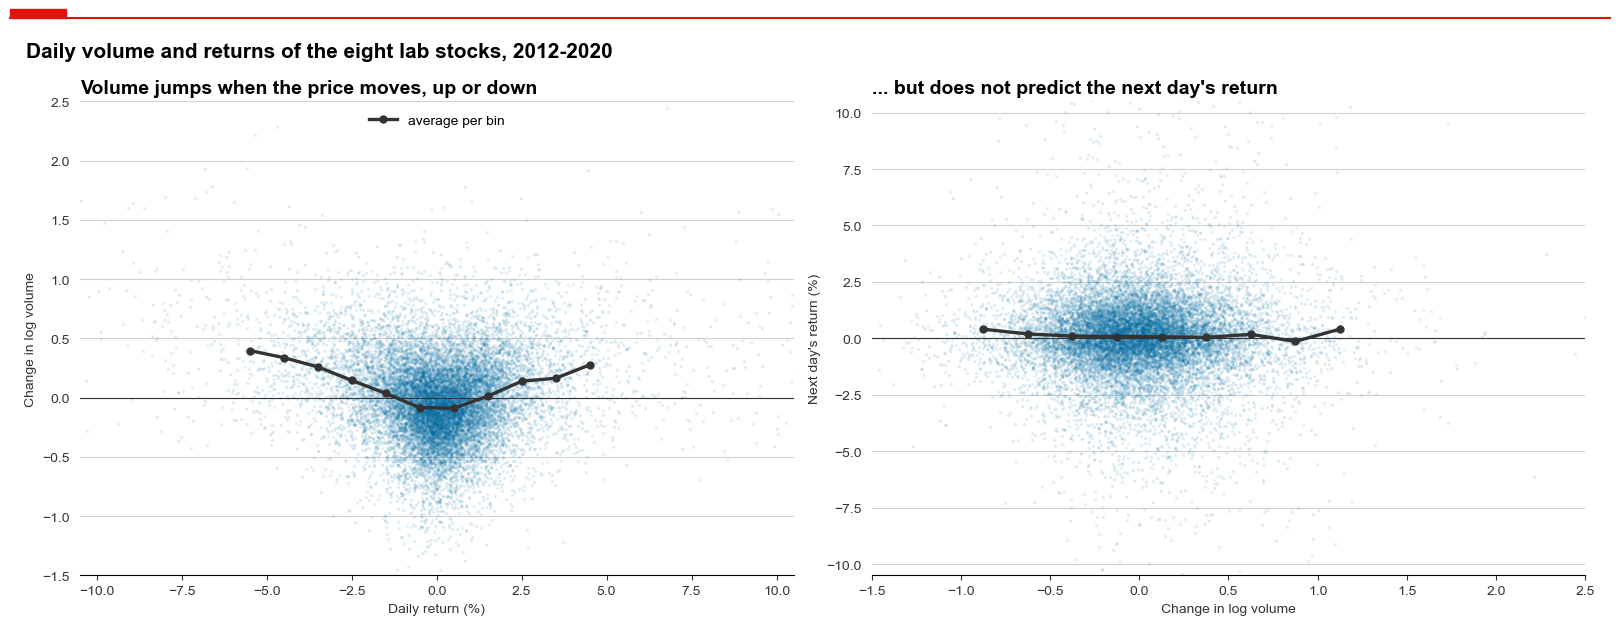

Average change in log volume by the size of the day's return: {'below 1%': -0.09, '1% to 3%': 0.05, '3% to 5%': 0.24, 'above 5%': 0.45}
Correlation with the change in log volume:
  return             the eight stocks -0.12 to +0.05, the S&P 500 -0.09
  absolute return    the eight stocks +0.27 to +0.47, the S&P 500 +0.13
  next day's return  the eight stocks -0.05 to +0.03, the S&P 500 -0.02


In [5]:
returns = prices.pct_change().dropna()
volume_change = np.log(volumes).diff().dropna()                     # daily change in log volume

correlations = pd.DataFrame({
    "return": returns.corrwith(volume_change),
    "absolute return": returns.abs().corrwith(volume_change),
    "next day's return": volume_change.corrwith(returns.shift(-1)),
})

pooled = pd.DataFrame({"return": returns[stocks].stack(), "volume change": volume_change[stocks].stack(),
                       "next day's return": returns[stocks].shift(-1).stack()}).dropna()      # the eight stocks, one row per stock-day
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
panels = [(axes[0], "return", "volume change", np.arange(-0.10, 0.1001, 0.01), (100, 1), (-10.5, 10.5), (-1.5, 2.5),
           "Daily return (%)", "Change in log volume", "Volume jumps when the price moves, up or down"),
          (axes[1], "volume change", "next day's return", np.arange(-1.5, 2.51, 0.25), (1, 100), (-1.5, 2.5), (-10.5, 10.5),
           "Change in log volume", "Next day's return (%)", "... but does not predict the next day's return")]
for ax, x, y, bins, (x_scale, y_scale), x_range, y_range, x_label, y_label, title in panels:
    ax.scatter(pooled[x] * x_scale, pooled[y] * y_scale, s=5, alpha=0.12, color=ECONOMIST_COLORS[0], lw=0, rasterized=True)
    grouped = pooled.groupby(pd.cut(pooled[x], bins), observed=True)[y]
    means = grouped.mean()[grouped.size() >= 100]                                  # bins with at least 100 stock-days
    ax.plot([interval.mid * x_scale for interval in means.index], means * y_scale, color="#333333", lw=2.4, marker="o", ms=5, label="average per bin")
    ax.axhline(0, color="#333333", lw=0.8)
    ax.set_xlim(*x_range)
    ax.set_ylim(*y_range)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(False, axis="x")
axes[0].legend(loc="upper center")
fig.suptitle("Daily volume and returns of the eight lab stocks, 2012-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()
size = pd.cut(pooled["return"].abs(), [0, 0.01, 0.03, 0.05, np.inf], labels=["below 1%", "1% to 3%", "3% to 5%", "above 5%"], include_lowest=True)
print("Average change in log volume by the size of the day's return:", pooled.groupby(size, observed=True)["volume change"].mean().round(2).to_dict())
print("Correlation with the change in log volume:")
for measure in correlations:
    print(f"  {measure:<18} the eight stocks {correlations.loc[stocks, measure].min():+.2f} to {correlations.loc[stocks, measure].max():+.2f}, "
          f"the S&P 500 {correlations.loc['sp500', measure]:+.2f}")

**Comments – 1.2**

- **Volume follows the size of the return, not its sign** (left): on days when a stock moves by more than 5%, its log volume rises by 0.45 on average, about 57% more shares; on days below 1% it falls by 0.09. The correlation with the absolute return lies between 0.27 and 0.47 for the stocks, with the return itself between −0.12 and +0.05: news brings in traders, good or bad (Karpoff, 1987).
- **Volume does not predict the next day's return** (right): the correlations lie between −0.05 and +0.03.
- **Hence volume enters Task #2 next to past returns:** price moves on high volume tend to reverse (Campbell, Grossman and Wang, 1993), a combination the nonlinear models of Task #3 can learn.

## Task #2 – Train and test samples, OLS and Ridge regression
### 2.1 Data, signals and targets
**Data.** Eight stocks are too few for machine learning and long-short portfolios (Gu et al., 2020, use nearly 30,000). We download daily prices and volumes, adjusted for splits and dividends, for the 503 tickers of PC Lab #2 and the index, from January 2011 so that the one-year signals have a history on the first day of the lab sample.

In [6]:
SP500_LIST = "sp500_tickers_pclab2.csv"                             # the S&P 500 list scraped in PC Lab #2
QUOTES_FILE = "sp500_ohlcv_2011-01-01_to_2020-08-11.csv.gz"         # Yahoo Finance download, cached on disk
DOWNLOAD_START = "2011-01-01"                                        # one year of history for the one-year signals
SAMPLE_START, SAMPLE_END = "2012-01-12", "2020-08-11"                # the window of the lab files
MARKET = "^GSPC"                                                     # Yahoo's ticker of the S&P 500 index


def load_quotes(cache=QUOTES_FILE):
    '''
    Daily open, high, low, close and volume of the PC Lab #2 S&P 500 list and of the index (Yahoo Finance),
    adjusted for splits and dividends. Cached on disk: the download takes about 20 seconds.
    '''
    if not os.path.exists(cache):
        import yfinance as yf                                            # only needed for the download
        tickers = pd.read_csv(SP500_LIST)["ticker"].tolist()
        end = pd.Timestamp(SAMPLE_END) + pd.Timedelta(days=1)            # yfinance treats the end date as exclusive
        quotes = yf.download(tickers + [MARKET], start=DOWNLOAD_START, end=end, auto_adjust=True, progress=False)
        quotes.dropna(axis=1, how="all").round(4).to_csv(cache)
    return pd.read_csv(cache, header=[0, 1], index_col=0, parse_dates=True)


quotes = load_quotes()
market_close = quotes[("Close", MARKET)]
quotes = quotes.drop(columns=MARKET, level=1)
close, volume = quotes["Close"], quotes["Volume"].where(quotes["Volume"] > 0)      # a zero volume is a missing record

traded = close.loc[SAMPLE_START:].notna()
print(f"Stocks with Yahoo data: {close.shape[1]} of the {len(pd.read_csv(SP500_LIST))} tickers, "
      f"{close.index[0]:%Y-%m-%d} to {close.index[-1]:%Y-%m-%d}")
print(f"Traded on the first day of the lab sample: {traded.iloc[0].sum()} | on the last day: {traded.iloc[-1].sum()} | on every day: {traded.all().sum()}")

agreement = close[stocks].assign(sp500=market_close).pct_change(fill_method=None).loc[returns.index].corrwith(returns)   # Yahoo vs lab file
print(f"Correlation of daily returns with the lab file: {agreement.min():.3f} to {agreement.max():.3f}, "
      f"{(agreement.round(3) == 1).sum()} of the {len(agreement)} series at 1.000")

Stocks with Yahoo data: 485 of the 503 tickers, 2011-01-03 to 2020-08-11
Traded on the first day of the lab sample: 436 | on the last day: 485 | on every day: 436
Correlation of daily returns with the lab file: 0.984 to 1.000, 6 of the 9 series at 1.000


**Comments – 2.1, the data**

- **485 of the 503 tickers have data;** the other 18 were listed after August 2020. 436 stocks trade on every day of the lab window and 49 were listed during it, so each day uses the stocks with the history a signal needs.
- **Returns agree with the lab file** (correlations of 0.984 to 1.000); the gaps for AT&T and IBM come from dividend and spin-off adjustments the lab file lacks.
- **Survivorship bias:** these are today's members, so companies that left the index since 2012 are missing and companies that grew into it are present, which raises average returns (PC Lab #2). 4.1 checks whether it drives the portfolio results.

**Signals and targets.** We predict the return of stock $i$ from the close of day $t$ to that of day $t+h$, $r_{i,t \to t+h} = P_{i,t+h}/P_{i,t} - 1$, for $h$ = 5 and 20 trading days; the slides' 60 days would leave the 2.2-year test period with fewer than nine non-overlapping quarters. The **four base signals** are the slides' information set over the past $w$ = 5 and 20 days:
- **Returns** (*return 5d*, *return 20d*): $P_{i,t}/P_{i,t-w} - 1$, for short-term reversal and momentum (Jegadeesh, 1990);
- **Volumes** (*volume 5d*, *volume 20d*): $\ln$(average volume of the past $w$ days / average volume of the past year), abnormal volume as a sign of news, measured against the stock's own past year (1.1).

The same function defines the eight signals of Task #2 bis.

**Scaling.** Each day every stock signal is ranked across stocks and mapped into $[-1, 1]$ (Gu et al., 2020, footnote 29), so outliers lose their weight and the scale does not drift between calm years and the crash. The market's returns, the same for all stocks on a day, get the slides' `MinMaxScaler`, fitted on the estimation days only.

In [7]:
HORIZONS = [5, 20]      # forecast horizons in trading days: a week and a month
WINDOWS = [5, 20]       # look-back windows of the price and volume signals
DAYS = 252              # trading days per year: the one-year signals here, annualising in Task #4

BASE = [f"return {w}d" for w in WINDOWS] + [f"volume {w}d" for w in WINDOWS]
EXTRA = ["beta", "volatility 20d", "max return 20d", "52-week high", "range position 20d", "dollar volume 20d"]
MARKET_SIGNALS = [f"market {w}d" for w in WINDOWS]
STOCK_SIGNALS = BASE + EXTRA
ALL_SIGNALS = STOCK_SIGNALS + MARKET_SIGNALS


def stock_signals(close, volume, high, low, market_close):
    '''Every signal of stock i known at the close of day t, one frame (days x stocks) per signal.'''
    returns, market_returns = close.pct_change(fill_method=None), market_close.pct_change()
    one_year = {"window": DAYS, "min_periods": 200}
    normal_volume = volume.rolling(**one_year).mean()                   # the stock's average day over the past year
    signals = {}
    for w in WINDOWS:
        signals[f"return {w}d"] = close / close.shift(w) - 1
        signals[f"volume {w}d"] = np.log(volume.rolling(w).mean() / normal_volume)
    signals["beta"] = returns.rolling(**one_year).cov(market_returns).div(market_returns.rolling(**one_year).var(), axis=0)
    signals["volatility 20d"] = returns.rolling(20).std()
    signals["max return 20d"] = returns.rolling(20).max()
    signals["52-week high"] = close / close.rolling(**one_year).max()
    signals["range position 20d"] = (close - low.rolling(20).min()) / (high.rolling(20).max() - low.rolling(20).min())
    signals["dollar volume 20d"] = np.log((close * volume).rolling(20).mean())
    return signals


def build_panel(signals, close, market_close):
    '''One row per stock and day of the lab window: the signals, the market's past returns and the h-day returns to predict.'''
    targets = {f"target {h}d": close.shift(-h) / close - 1 for h in HORIZONS}
    panel = pd.concat({name: frame.loc[SAMPLE_START:SAMPLE_END].stack() for name, frame in {**signals, **targets}.items()}, axis=1)
    panel.index.names = ["date", "ticker"]
    for w in WINDOWS:                                                    # the same value for every stock of a day
        panel[f"market {w}d"] = (market_close / market_close.shift(w) - 1).reindex(panel.index.get_level_values("date")).to_numpy()
    return panel.dropna(subset=STOCK_SIGNALS).astype("float32")


def rank_scale(frame):
    '''Cross-sectional rank of every signal, mapped to [-1, 1] each day (Gu et al., 2020, footnote 29).'''
    by_day = frame.groupby(level="date")
    return (2 * (by_day.rank() - 1) / (by_day.transform("count") - 1) - 1).astype("float32")


panel = build_panel(stock_signals(close, volume, quotes["High"], quotes["Low"], market_close), close, market_close)
scaled = rank_scale(panel[STOCK_SIGNALS])
dates = panel.index.get_level_values("date")
trading_days = dates.unique()
stocks_per_day = panel.groupby(level="date").size()

print(f"Panel: {len(panel):,} stock-days of {panel.index.get_level_values('ticker').nunique()} stocks on {len(trading_days):,} days, "
      f"{stocks_per_day.min()} to {stocks_per_day.max()} stocks a day")

Panel: 984,618 stock-days of 481 stocks on 2,159 days, 430 to 481 stocks a day


### 2.2 Splitting the sample
The split follows time: the first 75% of the 2,159 days train, the last 25% test. Hyperparameters, such as the Ridge penalty, are tuned on the last fifth of the training days (validation), as in Gu et al. (2020); all models are estimated on the remaining **estimation** days, and the test days are used once. The last $h$ days before each cut are dropped, so that no training target overlaps the next sample.

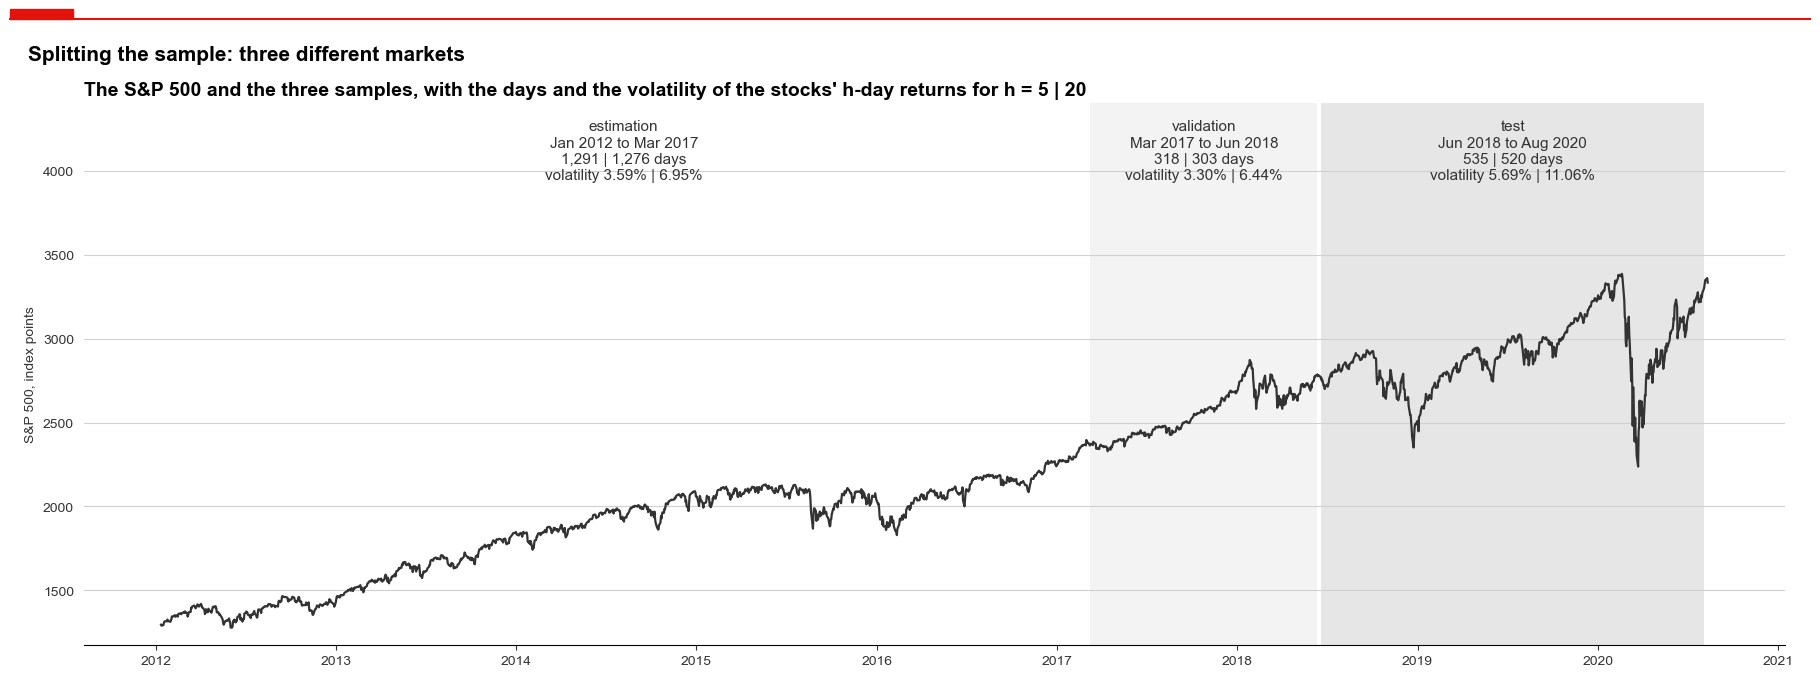

In [8]:
TRAIN_SHARE = 0.75      # the first 75% of the days train the models, the last 25% test them
VALID_SHARE = 0.20      # the last 20% of the training days tune them


def split_dates(days, horizon):
    '''
    Estimation, validation and test days. The last `horizon` days before each cut are dropped (purging),
    because their h-day returns would overlap the next sample.
    '''
    n_train = int(len(days) * TRAIN_SHARE)
    n_valid = int(n_train * VALID_SHARE)
    return {"estimation": days[:n_train - n_valid - horizon],
            "validation": days[n_train - n_valid:n_train - horizon],
            "test": days[n_train:len(days) - horizon]}


def design(horizon):
    '''Inputs, target and sample masks for one horizon. The market signals are min-max scaled on the estimation days.'''
    y = panel[f"target {horizon}d"].to_numpy(dtype="float64")
    masks = {name: dates.isin(days) & ~np.isnan(y) for name, days in split_dates(trading_days, horizon).items()}
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(panel.loc[masks["estimation"], MARKET_SIGNALS])
    market = pd.DataFrame(scaler.transform(panel[MARKET_SIGNALS]), index=panel.index, columns=MARKET_SIGNALS)
    return scaled.join(market).astype("float32"), y, masks


data = {h: design(h) for h in HORIZONS}

SAMPLES = ["estimation", "validation", "test"]
samples = pd.DataFrame({(h, name): {"first": dates[mask][0], "last": dates[mask][-1], "days": dates[mask].nunique(), "volatility": y[mask].std()}
                        for h, (X, y, masks) in data.items() for name, mask in masks.items()}).T

fig, ax = plt.subplots(figsize=(18, 6.5))
index_level = market_close.loc[SAMPLE_START:SAMPLE_END]
ax.plot(index_level.index, index_level, color="#333333", lw=1.6)
for name, shade in zip(SAMPLES, ["white", "#F3F3F3", "#E6E6E6"]):
    first, last = samples.loc[(HORIZONS[0], name), ["first", "last"]]
    ax.axvspan(first, last, color=shade, lw=0, zorder=0)
    days = " | ".join(f"{samples.loc[(h, name), 'days']:,}" for h in HORIZONS)
    volatility = " | ".join(f"{samples.loc[(h, name), 'volatility']:.2%}" for h in HORIZONS)
    ax.text(first + (last - first) / 2, 0.97, f"{name}\n{first:%b %Y} to {last:%b %Y}\n{days} days\nvolatility {volatility}",
            transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=11, color="#333333")
ax.set_ylim(top=index_level.max() * 1.3)                                  # room for the labels
ax.set_title("The S&P 500 and the three samples, with the days and the volatility of the stocks' h-day returns for h = 5 | 20")
ax.set_ylabel("S&P 500, index points")
ax.grid(False, axis="x")
fig.suptitle("Splitting the sample: three different markets", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**Comments – 2.2**

- **Three different markets:** a steady bull market in estimation (January 2012 to March 2017), the calmest sample in validation (March 2017 to June 2018, a 5-day volatility of 3.30%) and in the test (June 2018 to August 2020) the sell-off of December 2018 and the COVID crash, with a 5-day volatility of 5.69%, almost 60% above estimation (3.59%). The models are judged in a market unlike the one they learned from.
- **Overlap:** 20-day returns of consecutive days share 19 of their 20 days, so the 520 test days of the 20-day horizon hold only 26 non-overlapping months.

### 2.3 How we measure performance
- **$R^2_{OOS}$ of Gu et al. (2020, eq. 19)**, pooled over stocks and test days: $R^2_{OOS} = 1 - \sum (r_{i,t} - \hat r_{i,t})^2 / \sum r_{i,t}^2$. Its benchmark is a forecast of zero, as a single stock's historical mean is too noisy to be a meaningful one.
- **RMSE**, the root mean squared error: on the same days it ranks models as $R^2_{OOS}$ does, but reads as a typical error in percent.
- **Hit rate**, the slides' alternative: the share of stock-days whose forecast and return have the same sign.
- **Rank IC**, the information coefficient (Grinold and Kahn, 2000) in its rank form, so that a few extreme returns cannot dominate it: each day the Spearman correlation across stocks between forecasts and realised returns, averaged over the days (0 = a random ranking, as on a day the forecasts give every stock the same value). It judges only what a long-short portfolio needs, the ranking of stocks, and ignores the average return and the level of the market. Its **ICIR**, the average divided by the standard deviation over the days, measures how stable that ranking is.

Task #4 adds the economic measure, the Sharpe ratio of the portfolios built on the forecasts. Once 2.4 has shown the weaknesses of $R^2_{OOS}$, we benchmark only with the rank IC and the Sharpe ratio.

In [9]:
def r2_oos(y, prediction):
    '''Out-of-sample R2 of Gu et al. (2020, eq. 19): the benchmark is a forecast of zero.'''
    return 1 - np.sum((y - prediction) ** 2) / np.sum(y ** 2)


def rmse(y, prediction):
    '''Root mean squared error of a forecast.'''
    return np.sqrt(np.mean((y - prediction) ** 2))


def evaluate(y, prediction):
    '''R2_OOS, RMSE and hit rate of one forecast.'''
    return {"R2_OOS": r2_oos(y, prediction), "RMSE": rmse(y, prediction),
            "hit rate": np.mean(np.sign(prediction) == np.sign(y))}


def results(models):
    '''Test performance of the models, one row per horizon and model.'''
    rows = {}
    for h, (X, y, masks) in data.items():
        test = masks["test"]
        for model in models:
            rows[(f"{h}-day", model)] = evaluate(y[test], forecasts[h][model])
    return pd.DataFrame(rows).T


METRIC_FORMAT = {"R2_OOS": "{:.2%}", "RMSE": "{:.2%}", "hit rate": "{:.1%}"}

### 2.4 OLS and Ridge on the four base signals
Ridge adds the penalty $\alpha \sum_k \beta_k^2$ to the squared errors and shrinks the slopes towards zero, leaving the intercept free: as $\alpha \to \infty$ it becomes the **training mean**, the average estimation-day return forecast for every stock-day, our naive benchmark. We keep the best of 17 penalties from $10^1$ (almost OLS) to $10^9$ (almost the constant) on the validation days.

In [10]:
ALPHAS = np.logspace(1, 9, 17)              # Ridge penalties, from almost OLS to almost a constant


def ridge_path(X, y, masks, signals):
    '''Validation R2_OOS and coefficients of Ridge for every penalty, estimated on the estimation days.'''
    estimation, validation = masks["estimation"], masks["validation"]
    path = {}
    for alpha in ALPHAS:
        ridge = Ridge(alpha=alpha).fit(X.loc[estimation, signals], y[estimation])
        path[alpha] = {"validation R2": r2_oos(y[validation], ridge.predict(X.loc[validation, signals])), **dict(zip(signals, ridge.coef_))}
    return pd.DataFrame(path).T


def fit_linear(horizon, signals, label):
    '''OLS and the validated Ridge for one horizon. Their test forecasts go to `forecasts`, the Ridge path is returned.'''
    X, y, masks = data[horizon]
    estimation, test = masks["estimation"], masks["test"]
    path = ridge_path(X, y, masks, signals)
    for name, model in [("OLS", LinearRegression()), ("Ridge", Ridge(alpha=path["validation R2"].idxmax()))]:
        forecasts[horizon][f"{name} ({label})"] = model.fit(X.loc[estimation, signals], y[estimation]).predict(X.loc[test, signals])
    return path


forecasts = {h: {"training mean": np.full(masks["test"].sum(), y[masks["estimation"]].mean())} for h, (X, y, masks) in data.items()}
ridge_base = {h: fit_linear(h, BASE, "4 signals") for h in HORIZONS}

linear = results(["training mean", "OLS (4 signals)", "Ridge (4 signals)"])
for h, path in ridge_base.items():
    gain = path["validation R2"].max() - path["validation R2"].iloc[0]                  # against the smallest penalty, almost OLS
    print(f"{h}-day horizon: Ridge penalty chosen on the validation days {path['validation R2'].idxmax():.0e}, validation R2_OOS {gain:+.4%} against OLS")
linear.style.format(METRIC_FORMAT, na_rep="")

5-day horizon: Ridge penalty chosen on the validation days 3e+05, validation R2_OOS +0.0036% against OLS
20-day horizon: Ridge penalty chosen on the validation days 1e+01, validation R2_OOS +0.0000% against OLS


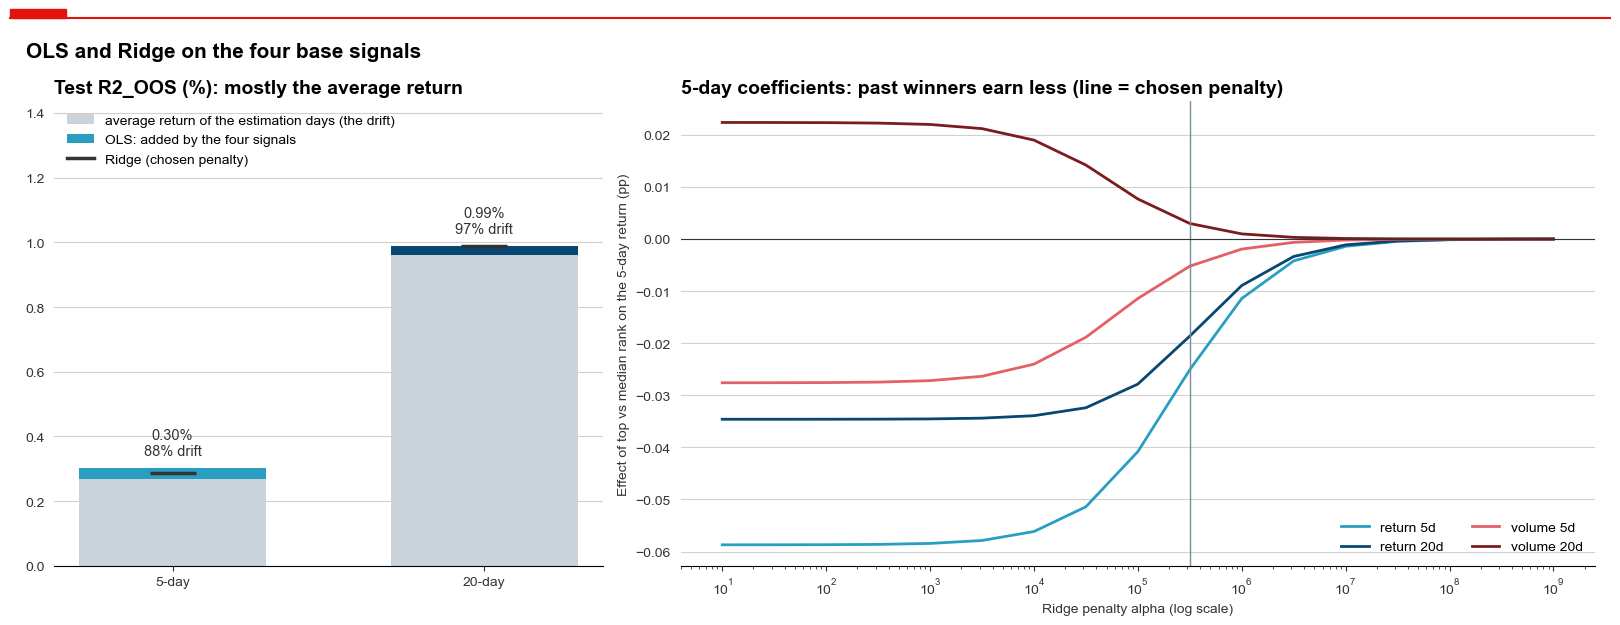

In [11]:
HORIZON_COLORS = dict(zip(HORIZONS, ECONOMIST_BLUES([0.45, 0.85])))   # one hue, darker = longer horizon (used to the end)
RETURN_COLORS = ECONOMIST_BLUES(np.linspace(0.45, 0.85, len(WINDOWS)))                                           # one per look-back window
VOLUME_COLORS = LinearSegmentedColormap.from_list("economist_reds", ["#F08A8E", "#DB444B", "#7A1B1E"])(np.linspace(0.3, 1.0, len(WINDOWS)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [0.6, 1]})
test_r2 = {model: np.array([linear.loc[(f"{h}-day", model), "R2_OOS"] for h in HORIZONS]) * 100
           for model in ["training mean", "OLS (4 signals)", "Ridge (4 signals)"]}
positions = np.arange(len(HORIZONS))
axes[0].bar(positions, test_r2["training mean"], width=0.6, color=LIGHT_GREY, label="average return of the estimation days (the drift)")
axes[0].bar(positions, test_r2["OLS (4 signals)"] - test_r2["training mean"], bottom=test_r2["training mean"], width=0.6,
            color=[HORIZON_COLORS[h] for h in HORIZONS], label="OLS: added by the four signals")
axes[0].scatter(positions, test_r2["Ridge (4 signals)"], marker="_", s=1100, linewidths=2.5, color="#333333", zorder=3, label="Ridge (chosen penalty)")
for x, drift, total in zip(positions, test_r2["training mean"], test_r2["OLS (4 signals)"]):
    axes[0].annotate(f"{total:.2f}%\n{drift / total:.0%} drift", (x, total), xytext=(0, 9), textcoords="offset points",
                     ha="center", fontsize=10.5, color="#333333")
axes[0].set_xticks(positions, [f"{h}-day" for h in HORIZONS])
axes[0].set_ylim(0, test_r2["OLS (4 signals)"].max() * 1.45)
axes[0].set_title("Test R2_OOS (%): mostly the average return")
handles, names = axes[0].get_legend_handles_labels()
handles[names.index("Ridge (chosen penalty)")] = plt.Line2D([], [], color="#333333", lw=2.5)
labels = ["average return of the estimation days (the drift)", "OLS: added by the four signals", "Ridge (chosen penalty)"]
axes[0].legend([handles[names.index(name)] for name in labels], labels, loc="upper left", fontsize=10)

path = ridge_base[5]
for signal, color in zip(BASE, list(RETURN_COLORS) + list(VOLUME_COLORS)):
    axes[1].plot(path.index, path[signal] * 100, color=color, lw=2, label=signal)
axes[1].axvline(path["validation R2"].idxmax(), color=GREY, lw=1)
axes[1].axhline(0, color="#333333", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("Ridge penalty alpha (log scale)")
axes[1].set_title("5-day coefficients: past winners earn less (line = chosen penalty)")
axes[1].set_ylabel("Effect of top vs median rank on the 5-day return (pp)")
axes[1].legend(loc="lower right", ncol=2, fontsize=10)
for ax in axes:
    ax.grid(False, axis="x")
fig.suptitle("OLS and Ridge on the four base signals", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**Comments – Task #2**

- **$R^2_{OOS}$ is positive but almost all average return** (left): OLS reaches 0.30% and 0.99% (5 and 20 days), the training mean alone 0.27% and 0.96%.
- **Ridge barely matters:** the validation days pick the smallest penalty at 20 days, so Ridge equals OLS, and 300,000 at 5 days, which gains 0.004 pp on the validation days and loses 0.02 pp on the test days. Shrinkage pays with many signals, as in Gu et al. (2020), not with four coefficients and half a million stock-days.
- **The coefficients show short-term reversal** (right): last week's top stock is expected to earn 0.06 pp less than the median stock next week (Jegadeesh, 1990), against a 5-day volatility of 5.69%.

**Is $R^2_{OOS}$ a good metric?** To compare forecasts on the same test days, yes. As a measure of skill, no: (1) the zero benchmark lets the average return pass for skill, 88% and 97% of OLS's $R^2_{OOS}$; (2) a few volatile days dominate the squared errors; (3) it punishes the size of forecasts, not only their order, so a model that ranks stocks well can still score below zero. RMSE is no way out: built on the same squared errors, it ranks models as $R^2_{OOS}$ does (2.3) and shares all three weaknesses. The hit rate only shows that every forecast is positive: it equals the share of positive returns (55.8% and 59.4%). From here on we therefore benchmark with two measures only: the rank IC, which judges the ranking of stocks a portfolio needs and avoids all three weaknesses (it ignores the average return, weighs every day equally and ignores the size of the forecasts), and the Sharpe ratio of the portfolios built on the forecasts (Task #4, Conclusion).

## Task #2 bis – Improving the model?
We add eight signals in two groups:
- **The market**, "closer to the theory": the S&P 500's return over the past 5 and 20 days. Under the CAPM, $E[r_i] = \beta_i\, E[r_M]$, a predictable market return moves each stock in proportion to its beta, so the one-year **beta** of PC Lab #2 enters too.
- **More price and volume signals** from the groups that dominate in Gu et al. (2020, Figure 5): 20-day **volatility** and **maximum daily return** (Bali, Cakici and Whitelaw, 2011), the distance to the **52-week high** (George and Hwang, 2004), **dollar volume** for liquidity, and the **range position**, where the close sits in the past 20 days' high-low range, a pattern Jiang et al. (2023) single out.

The tweets of PC Lab #3 stay out: they cover 25 symbols, not 485, and did not predict returns there.

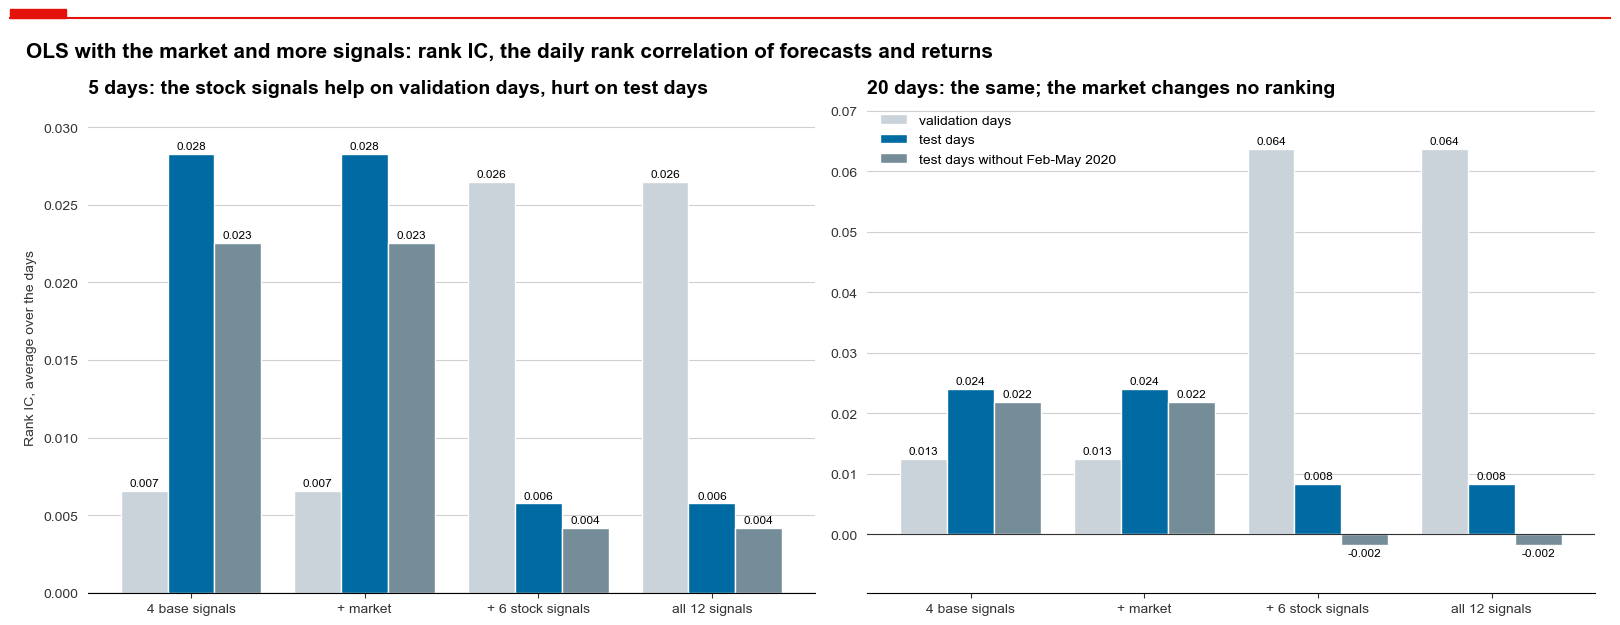

In [12]:
SETS = {"4 base signals": BASE, "+ market": BASE + MARKET_SIGNALS, "+ 6 stock signals": STOCK_SIGNALS, "all 12 signals": ALL_SIGNALS}
COVID = (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-31"))      # the crash and the rebound


def daily_rank_ic(y, prediction, days):
    '''Each day's Spearman correlation across stocks between forecasts and realised returns; 0 on a day the forecasts rank no stock.'''
    frame = pd.DataFrame({"forecast": np.asarray(prediction, dtype=float), "realised": np.asarray(y, dtype=float)})
    day = np.asarray(days)
    ranks = frame.groupby(day).rank()
    ranks -= ranks.groupby(day).transform("mean")                         # demeaned ranks: their normalised product is the correlation
    product = (ranks["forecast"] * ranks["realised"]).groupby(day).sum()
    correlation = product / np.sqrt((ranks["forecast"] ** 2).groupby(day).sum() * (ranks["realised"] ** 2).groupby(day).sum())
    return correlation.fillna(0.0)                                         # the same forecast for every stock: no ranking


def rank_ic(y, prediction, days):
    '''Average daily rank IC and its ICIR (average / standard deviation over the days; 0 for forecasts that never rank).'''
    daily = daily_rank_ic(y, prediction, days)
    return daily.mean(), (daily.mean() / daily.std() if daily.std() > 0 else 0.0)


by_set = {}
for h, (X, y, masks) in data.items():
    estimation, validation, test = masks["estimation"], masks["validation"], masks["test"]
    calm = test & ~((dates >= COVID[0]) & (dates <= COVID[1]))
    for name, signals in SETS.items():
        predicted = LinearRegression().fit(X.loc[estimation, signals], y[estimation]).predict(X[signals])
        by_set[(h, name)] = {sample: rank_ic(y[mask], predicted[mask], dates[mask])[0]
                             for sample, mask in [("validation days", validation), ("test days", test), ("test days without Feb-May 2020", calm)]}
by_set = pd.DataFrame(by_set).T

ridge_all = {h: fit_linear(h, ALL_SIGNALS, "12 signals") for h in HORIZONS}   # Task #3's linear benchmarks

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(16, 6))
titles = {5: "5 days: the stock signals help on validation days, hurt on test days", 20: "20 days: the same; the market changes no ranking"}
for ax, h in zip(axes, HORIZONS):
    part = by_set.xs(h, level=0)
    positions = np.arange(len(part))
    for i, (column, color) in enumerate([("validation days", LIGHT_GREY), ("test days", ECONOMIST_COLORS[0]), ("test days without Feb-May 2020", GREY)]):
        bars = ax.bar(positions + (i - 1) * 0.27, part[column], width=0.27, color=color, edgecolor="white", linewidth=1, label=column)
        ax.bar_label(bars, fmt="%.3f", fontsize=8.5, padding=2)
    ax.axhline(0, color="#333333", lw=0.8)
    ax.set_xticks(positions, part.index)
    ax.set_title(titles[h])
    ax.margins(y=0.12)
    ax.grid(False, axis="x")
axes[0].set_ylabel("Rank IC, average over the days")
axes[1].legend(loc="upper left", fontsize=10)
fig.suptitle("OLS with the market and more signals: rank IC, the daily rank correlation of forecasts and returns", x=0.01,
             ha="left", fontsize=15, fontweight="bold")
show()

**Comments – Task #2 bis**

- **"Closer to the theory"? For a linear model the market changes nothing.** Under the CAPM a predictable market return moves each stock in proportion to its beta, but a linear model adds the same market term to every stock: the ranking of stocks, and with it the rank IC, stays exactly the same with and without the market (0.028 and 0.024 on the test days). The interaction beta × market needs a nonlinear model (tested in 3.4).
- **The six stock signals help on validation and hurt on test:** they raise the rank IC on the validation days from 0.007 to 0.026 (5 days) and from 0.013 to 0.064 (20 days), but lower it on the test days from 0.028 to 0.006 and from 0.024 to 0.008, also without February to May 2020. What ranked stocks in the calm market of 2017-18 failed in 2018-20.
- **For Task #3** we keep all 12 signals, the best set on the validation days (Gu et al.'s criterion), knowing that on the test days the four base signals ranked stocks better.

## Task #3 – Machine learning models
### 3.1 Why these models
A linear model gives each signal the same effect on every stock in every market. The models below, from the families Gu et al. (2020) compare, can learn more, such as a beta that matters more right after a crash. All use the same 12 signals.
- **Elastic net**: a linear model that can switch off signals; the validation days choose how strongly.
- **Bayesian ridge**: a linear model that learns from the data how much to trust the signals, and how uncertain each forecast is.
- **Random forest**: 300 decision trees, each grown on a random part of the data, then averaged. Trees catch thresholds and interactions; averaging smooths out the noise. The validation days choose the size of the trees and how many signals each split may try.
- **XGBoost**: small trees grown one after another, each correcting the errors of the ones before; the validation days choose their size, number and learning rate.
- **NN3**: Gu et al.'s best model, a small neural network with three hidden layers that can learn smooth interactions, such as beta times the market's recent move. The validation days choose its penalty on large weights and its learning rate.

In [13]:
SEED = 42                # fixed random seed, so every run draws the same numbers (also the Monte Carlo of Task #4)


def validation_ic(prediction, y, masks):
    '''Rank IC of a forecast on the validation days, the criterion of every choice made there.'''
    validation = masks["validation"]
    return rank_ic(y[validation], prediction, dates[validation])[0]


def fit_forest(X, y, masks, signals=ALL_SIGNALS, leaves=(8, 32, 128), shares=(0.25, 0.5, 0.75)):
    '''
    Random forest (LightGBM in random-forest mode): 300 trees, each grown on a random fifth of the estimation days. Of the numbers
    of leaves and shares of the signals tried at each split, the forest with the highest validation rank IC wins.
    Returns it and the validation rank IC of every combination.
    '''
    estimation, validation = masks["estimation"], masks["validation"]
    grid, best = {}, None
    for n in leaves:
        for share in shares:
            forest = lgb.LGBMRegressor(boosting_type="rf", n_estimators=300, num_leaves=n, min_child_samples=2000, subsample=0.2,
                                       subsample_freq=1, feature_fraction_bynode=share, random_state=SEED, verbose=-1)
            forest.fit(X.loc[estimation, signals], y[estimation])
            grid[(n, share)] = validation_ic(forest.predict(X.loc[validation, signals]), y, masks)
            if grid[(n, share)] >= max(grid.values()):
                best = forest
    return best, grid


EN_ALPHAS = np.logspace(-2, -6, 9)        # elastic-net penalties, from all coefficients at zero to almost OLS
EN_L1_RATIOS = [0.1, 0.5, 0.9]             # share of the lasso in the penalty


def fit_elastic_net(X, y, masks, signals=ALL_SIGNALS):
    '''Elastic net with the penalty and lasso share that maximise the validation rank IC (each fit starts from the previous one).'''
    estimation, validation = masks["estimation"], masks["validation"]
    best_score, best = -np.inf, None
    for l1_ratio in EN_L1_RATIOS:
        model = ElasticNet(l1_ratio=l1_ratio, warm_start=True, max_iter=5000)
        for alpha in EN_ALPHAS:
            model.set_params(alpha=alpha).fit(X.loc[estimation, signals], y[estimation])
            score = validation_ic(model.predict(X.loc[validation, signals]), y, masks)
            if score > best_score:
                best_score, best = score, copy.deepcopy(model)
    return best


def fit_xgboost(X, y, masks, signals=ALL_SIGNALS, depths=(1, 2, 3), rates=(0.01, 0.1), trees=(10, 25, 50, 100, 200, 300, 500, 750, 1000)):
    '''XGBoost with the depth, learning rate and number of trees that give the highest validation rank IC.'''
    estimation, validation = masks["estimation"], masks["validation"]
    scores = {}
    for depth in depths:
        for rate in rates:
            booster = xgb.XGBRegressor(n_estimators=max(trees), max_depth=depth, learning_rate=rate, tree_method="hist", random_state=SEED)
            booster.fit(X.loc[estimation, signals], y[estimation])
            for n in trees:                                                  # the first n trees, scored without refitting
                scores[(depth, rate, n)] = validation_ic(booster.predict(X.loc[validation, signals], iteration_range=(0, n)), y, masks)
    depth, rate, n = max(scores, key=scores.get)
    return xgb.XGBRegressor(n_estimators=n, max_depth=depth, learning_rate=rate, tree_method="hist", random_state=SEED).fit(
        X.loc[estimation, signals], y[estimation])


def nn3(n_inputs=len(ALL_SIGNALS)):
    '''NN3 of Gu et al. (2020): hidden layers of 32, 16 and 8 ReLU neurons, each with batch normalisation.'''
    layers, width = [], n_inputs
    for neurons in [32, 16, 8]:
        layers += [nn.Linear(width, neurons), nn.BatchNorm1d(neurons), nn.ReLU()]
        width = neurons
    return nn.Sequential(*layers, nn.Linear(width, 1))

In [14]:
def train_networks(make, X_fit, y_fit, X_val, y_val, val_days, seeds=range(20), epochs=40, patience=4, batch=2048, lr=1e-3, l1=1e-5):
    '''Gu et al. (2020) recipe with Adam and an L1 penalty on the weights; each network keeps the epoch with the best validation rank IC.'''
    X_fit, y_fit = (torch.as_tensor(np.asarray(a, dtype=np.float32)) for a in (X_fit, y_fit))
    y_val = np.asarray(y_val, dtype=np.float64)
    networks = []
    for seed in seeds:
        torch.manual_seed(seed)
        network = make()
        optimizer = torch.optim.Adam(network.parameters(), lr=lr)
        best_score, waited = -np.inf, 0
        for epoch in range(1, epochs + 1):
            network.train()
            for rows in torch.randperm(len(X_fit)).split(batch):
                loss = nn.functional.mse_loss(network(X_fit[rows]).squeeze(-1), y_fit[rows])
                loss = loss + l1 * sum(w.abs().sum() for name, w in network.named_parameters() if "weight" in name)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            score = rank_ic(y_val, predict([network], X_val), val_days)[0]
            if score > best_score:
                best_score, best_state, waited = score, copy.deepcopy(network.state_dict()), 0
            else:
                waited += 1
                if waited == patience:
                    break
        network.load_state_dict(best_state)
        networks.append(network)
    return networks


def predict(networks, X):
    '''Average forecast of an ensemble of networks.'''
    X = torch.as_tensor(np.asarray(X, dtype=np.float32))
    outputs = []
    for network in networks:
        network.eval()
        with torch.no_grad():
            outputs.append(torch.cat([network(rows).squeeze(-1) for rows in X.split(65_536)]))
    return torch.stack(outputs).mean(0).numpy()


NN_GRID = [(l1, lr) for l1 in (1e-5, 1e-4, 1e-3) for lr in (1e-3, 1e-2)]   # L1 penalty x learning rate, the grid of Gu et al. (2020)


def tune_networks(X, y, masks, signals=ALL_SIGNALS, grid=NN_GRID, seeds=range(20), trials=5):
    '''
    NN3 tuned as in Gu et al. (2020): for every L1 penalty and learning rate, 5 networks are trained and the rank IC of their average
    forecast is measured on the validation days; the other 15 networks of the ensemble use the best pair. Returns the networks and the grid.
    '''
    estimation, validation = masks["estimation"], masks["validation"]
    samples = (X.loc[estimation, signals], y[estimation], X.loc[validation, signals], y[validation], dates[validation])
    make = lambda: nn3(len(signals))
    networks, scores = {}, {}
    for l1, lr in grid:
        networks[(l1, lr)] = train_networks(make, *samples, seeds=list(seeds)[:trials], lr=lr, l1=l1)
        scores[(l1, lr)] = validation_ic(predict(networks[(l1, lr)], X.loc[validation, signals]), y, masks)
    l1, lr = max(scores, key=scores.get)
    return networks[(l1, lr)] + train_networks(make, *samples, seeds=list(seeds)[trials:], lr=lr, l1=l1), scores

### 3.2 Training
The models minimise squared errors, as in Gu et al. (2020), but every choice made on the validation days follows the rank IC, the measure we benchmark with (2.4): the forest's number of leaves (8, 32 or 128) and share of the signals tried at each split (a quarter, half or three quarters); NN3's L1 penalty ($10^{-5}$, $10^{-4}$ or $10^{-3}$) and learning rate (0.001 or 0.01), each pair scored by the average of 5 networks, and the epoch each network keeps (it stops once its validation rank IC has not improved for 4 epochs); XGBoost's depth (1 to 3), learning rate (0.01 or 0.1) and number of trees (10 to 1,000); the penalties of Ridge and the elastic net. A single network depends on its random start, and a top-10 portfolio on small differences between forecasts, so NN3 averages 20 networks (Gu et al.: 10). For 3.4 every model is re-estimated with the same settings on the 10 stock signals, without the market. Training takes about 12 minutes, so the forecasts of the forest, XGBoost and NN3 are stored on disk: a re-run loads them without PyTorch or LightGBM. The other models take seconds and are fitted on every run.

In [15]:
FORECAST_CACHE = "pclab4_ml_forecasts.npz"
ML_KEYS = {"Random forest": "forest", "XGBoost": "xgb", "NN3": "nn3"}   # names of their forecasts on disk


def ols(y, x, hac_lags=0):
    '''
    OLS of y on a constant and x, estimated with statsmodels (as in PC Labs #2 and #3).
    hac_lags > 0 returns Newey-West standard errors.
    '''
    model = sm.OLS(np.asarray(y, dtype=float), sm.add_constant(np.asarray(x, dtype=float)))
    if hac_lags:
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return model.fit()


def train_models():
    '''
    Tune and train the forest, XGBoost and NN3 for every horizon. Returns as named arrays their forecasts for the validation and test days,
    their test forecasts without the market signals (same settings), the tuning grids and XGBoost's settings.
    '''
    out = {}
    for h, (X, y, masks) in data.items():
        estimation, validation, test = masks["estimation"], masks["validation"], masks["test"]
        forest, forest_grid = fit_forest(X, y, masks)
        booster = fit_xgboost(X, y, masks)
        networks, nn3_grid = tune_networks(X, y, masks)
        (n, share), (l1, lr) = max(forest_grid, key=forest_grid.get), max(nn3_grid, key=nn3_grid.get)
        forest_stock = fit_forest(X, y, masks, STOCK_SIGNALS, leaves=[n], shares=[share])[0]
        booster_stock = clone(booster).fit(X.loc[estimation, STOCK_SIGNALS], y[estimation])
        networks_stock = train_networks(lambda: nn3(len(STOCK_SIGNALS)), X.loc[estimation, STOCK_SIGNALS], y[estimation],
                                        X.loc[validation, STOCK_SIGNALS], y[validation], dates[validation], lr=lr, l1=l1)
        for key, model, model_stock in [("forest", forest.predict, forest_stock.predict), ("xgb", booster.predict, booster_stock.predict),
                                        ("nn3", lambda Z: predict(networks, Z), lambda Z: predict(networks_stock, Z))]:
            out.update({f"{key}_{h}": model(X.loc[test, ALL_SIGNALS]), f"{key}_validation_{h}": model(X.loc[validation, ALL_SIGNALS]),
                        f"{key}_stock_{h}": model_stock(X.loc[test, STOCK_SIGNALS])})
        out.update({f"forest_grid_{h}": np.array([[a, b, score] for (a, b), score in forest_grid.items()]),
                    f"nn3_grid_{h}": np.array([[a, b, score] for (a, b), score in nn3_grid.items()]),
                    f"xgb_settings_{h}": np.array([booster.max_depth, booster.learning_rate, booster.n_estimators]),
                    f"xgb_signals_{h}": np.array([signal in booster.get_booster().get_score() for signal in ALL_SIGNALS])})
    return out


def cached_forecasts(train, cache=FORECAST_CACHE):
    '''The trained models' forecasts, stored on disk: training takes minutes, loading a second.'''
    if not os.path.exists(cache):
        np.savez_compressed(cache, **train())
    with np.load(cache) as stored:
        return {key: stored[key] for key in stored.files}


def refit(model, X, y, masks, signals):
    '''The same model with the same settings, estimated on other signals.'''
    return clone(model).fit(X.loc[masks["estimation"], signals], y[masks["estimation"]])


ml = cached_forecasts(train_models)
validation_forecasts, stock_forecasts, linear_models = {h: {} for h in HORIZONS}, {h: {} for h in HORIZONS}, {}   # for 3.3 to 3.5
for h, (X, y, masks) in data.items():
    estimation, validation, test = masks["estimation"], masks["validation"], masks["test"]
    for name, key in ML_KEYS.items():
        forecasts[h][name], validation_forecasts[h][name], stock_forecasts[h][name] = (ml[f"{key}{part}_{h}"] for part in ["", "_validation", "_stock"])
    # the linear models, the elastic net and Bayesian ridge take seconds, so they are fitted on every run
    path = ridge_all[h]                                                      # Ridge's coefficients for every penalty (2 bis)
    alpha = max(path.index, key=lambda a: validation_ic(X.loc[validation, ALL_SIGNALS].to_numpy() @ path.loc[a, ALL_SIGNALS].to_numpy(), y, masks))
    enet = fit_elastic_net(X, y, masks)
    bayes = BayesianRidge().fit(X.loc[estimation, ALL_SIGNALS], y[estimation])
    fitted = {"OLS (12 signals)": refit(LinearRegression(), X, y, masks, ALL_SIGNALS), "Ridge (12 signals)": refit(Ridge(alpha=alpha), X, y, masks, ALL_SIGNALS),
              "Elastic net": enet, "Bayesian ridge": bayes}
    linear_models[h] = fitted
    for name, model in fitted.items():
        forecasts[h][name] = model.predict(X.loc[test, ALL_SIGNALS])
        validation_forecasts[h][name] = model.predict(X.loc[validation, ALL_SIGNALS])
        stock_forecasts[h][name] = refit(model, X, y, masks, STOCK_SIGNALS).predict(X.loc[test, STOCK_SIGNALS])
    forest_grid, nn3_grid = ml[f"forest_grid_{h}"], ml[f"nn3_grid_{h}"]
    (n, share), (l1, lr) = forest_grid[forest_grid[:, 2].argmax(), :2], nn3_grid[nn3_grid[:, 2].argmax(), :2]
    depth, rate, trees = ml[f"xgb_settings_{h}"]
    std = bayes.predict(X.loc[test, ALL_SIGNALS], return_std=True)[1]
    print(f"{h}-day horizon | NN3: L1 penalty {l1:.0e}, learning rate {lr:g} | forest: {n:.0f} leaves, {share:.0%} of the signals at each split | "
          f"XGBoost: depth {depth:.0f}, learning rate {rate:g}, {trees:.0f} trees, splitting on {ml[f'xgb_signals_{h}'].sum()} of {len(ALL_SIGNALS)} signals")
    print(f"{' ' * len(f'{h}-day horizon')} | Ridge: penalty {alpha:.0e} | elastic net: penalty {enet.alpha:.0e}, lasso share {enet.l1_ratio}, "
          f"{np.sum(enet.coef_ != 0)} of {len(ALL_SIGNALS)} signals kept | Bayesian ridge: penalty {bayes.lambda_ / bayes.alpha_:.0e}, coefficient "
          f"uncertainty adds {np.sqrt(np.mean(std ** 2 - 1 / bayes.alpha_)):.3%} to a forecast's standard deviation, the noise {1 / np.sqrt(bayes.alpha_):.2%}")

5-day horizon | NN3: L1 penalty 1e-05, learning rate 0.01 | forest: 32 leaves, 25% of the signals at each split | XGBoost: depth 2, learning rate 0.1, 500 trees, splitting on 12 of 12 signals
              | Ridge: penalty 1e+05 | elastic net: penalty 3e-05, lasso share 0.5, 11 of 12 signals kept | Bayesian ridge: penalty 1e+02, coefficient uncertainty adds 0.021% to a forecast's standard deviation, the noise 3.58%


20-day horizon | NN3: L1 penalty 1e-05, learning rate 0.01 | forest: 8 leaves, 25% of the signals at each split | XGBoost: depth 1, learning rate 0.1, 500 trees, splitting on 11 of 12 signals
               | Ridge: penalty 1e+05 | elastic net: penalty 3e-05, lasso share 0.9, 10 of 12 signals kept | Bayesian ridge: penalty 2e+02, coefficient uncertainty adds 0.042% to a forecast's standard deviation, the noise 6.92%


### 3.3 Results
Every model on the same 12 signals: its rank IC on the test days (coloured dots, with the ICIR) and on the validation days on which its settings were chosen (grey dots). At zero a model ranks the stocks no better than chance.

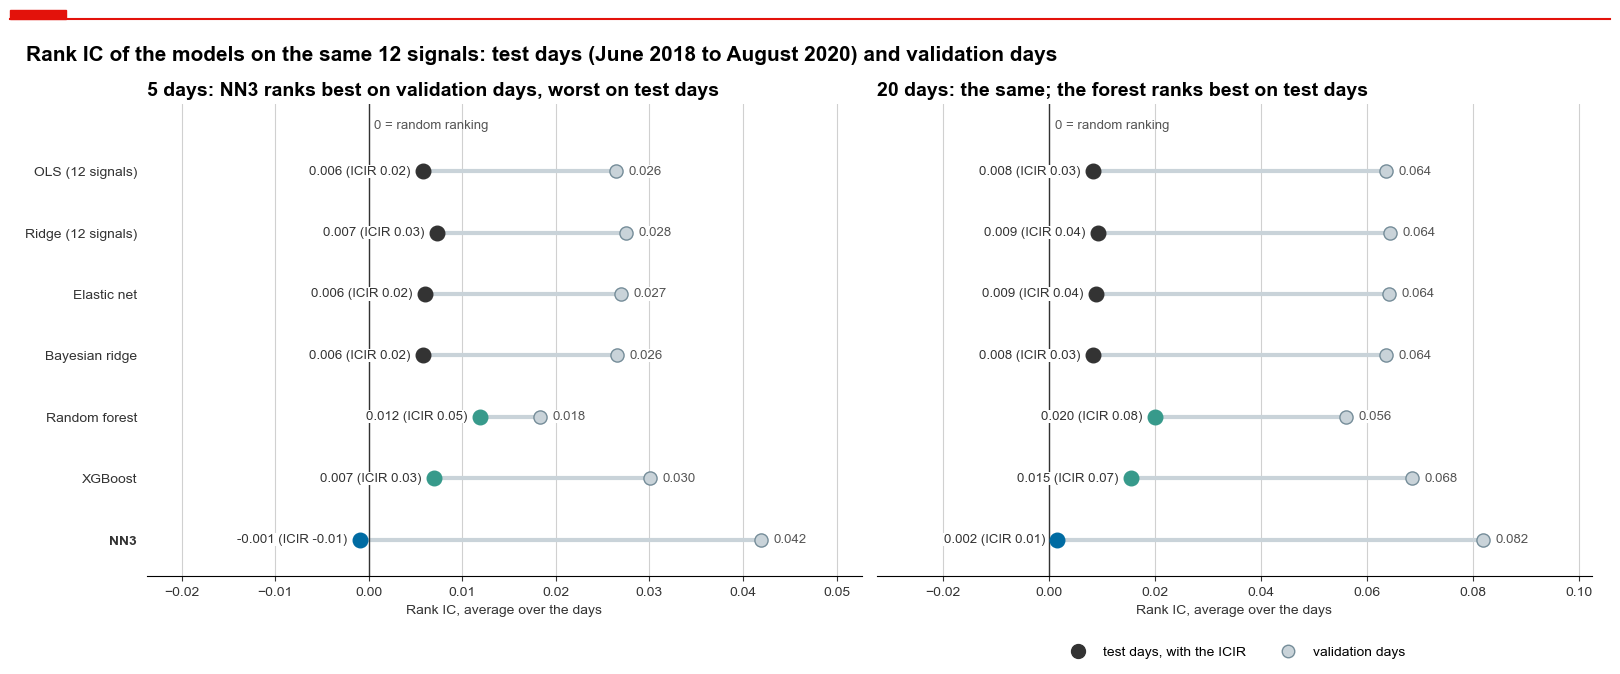

In [16]:
MODELS = ["OLS (12 signals)", "Ridge (12 signals)", "Elastic net", "Bayesian ridge", "Random forest", "XGBoost", "NN3"]
MODEL_COLORS = {**dict.fromkeys(MODELS[:4], "#333333"), "Random forest": "#379A8B", "XGBoost": "#379A8B",
                "NN3": ECONOMIST_COLORS[0]}                                       # colour = model family (also in 3.4 and the Conclusion)


def rank_ic_by_sample(h):
    '''Every model's rank IC and ICIR on the validation and on the test days.'''
    X, y, masks = data[h]
    rows = {(model, sample): rank_ic(y[masks[sample]], source[h][model], dates[masks[sample]])
            for model in MODELS for sample, source in [("validation", validation_forecasts), ("test", forecasts)]}
    return pd.DataFrame(rows, index=["rank IC", "ICIR"]).T


ic_samples = {h: rank_ic_by_sample(h) for h in HORIZONS}
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
rows = np.arange(len(MODELS))
titles = {5: "5 days: NN3 ranks best on validation days, worst on test days", 20: "20 days: the same; the forest ranks best on test days"}
for ax, h in zip(axes, HORIZONS):
    test, validation = ic_samples[h].xs("test", level=1), ic_samples[h].xs("validation", level=1)
    for row, model in zip(rows, MODELS):
        ic, icir, before = test.loc[model, "rank IC"], test.loc[model, "ICIR"], validation.loc[model, "rank IC"]
        ax.plot([before, ic], [row, row], color=LIGHT_GREY, lw=3, zorder=1)
        ax.scatter(before, row, s=90, color=LIGHT_GREY, edgecolors=GREY, linewidths=1, zorder=2)
        ax.scatter(ic, row, s=110, color=MODEL_COLORS[model], zorder=3)
        side = 1 if ic >= before else -1                                  # each label on its own side of the pair
        ax.annotate(f"{ic:.3f} (ICIR {icir:.2f})", (ic, row), xytext=(9 * side, 0), textcoords="offset points", va="center", fontsize=9.5,
                    ha="left" if side > 0 else "right", color="#333333", bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
        ax.annotate(f"{before:.3f}", (before, row), xytext=(-9 * side, 0), textcoords="offset points", va="center", fontsize=9.5,
                    ha="right" if side > 0 else "left", color="#555555", bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
    ax.axvline(0, color="#333333", lw=1)
    ax.annotate("0 = random ranking", (0, -0.75), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9.5, color="#555555")
    ax.margins(x=0.25)
    ax.set_xlim(left=ax.get_xlim()[0] - 0.012)                              # room for labels left of negative values
    ax.set_title(titles[h])
    ax.set_xlabel("Rank IC, average over the days")
    ax.grid(False, axis="y")
    ax.grid(True, axis="x", color="#D0D0D0")
axes[0].set_yticks(rows, MODELS)
axes[0].set_ylim(len(MODELS) - 0.4, -1.1)                                 # top to bottom, with room for the label of the zero line
for label in axes[0].get_yticklabels():
    label.set_fontweight("bold" if label.get_text() == "NN3" else "normal")
axes[1].legend(handles=[plt.Line2D([], [], marker="o", ls="", color="#333333", ms=10, label="test days, with the ICIR"),
                        plt.Line2D([], [], marker="o", ls="", markerfacecolor=LIGHT_GREY, markeredgecolor=GREY, ms=9, label="validation days")],
               loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10)
fig.suptitle("Rank IC of the models on the same 12 signals: test days (June 2018 to August 2020) and validation days", x=0.01, ha="left",
             fontsize=15, fontweight="bold")
show()

**Main point.** No model ranks the stocks much better than chance on the test days (rank IC 0.020 at most), and the validation days misled: NN3, the best model there at both horizons, ranks worst on the test days.

### 3.4 Do the models need the market signals?
2 bis argued that the S&P 500's past returns can only change the ranking of stocks through a nonlinear model. Each model is therefore re-estimated with the same settings on the 10 stock signals alone (hollow dots) and compared with its forecasts on all 12 signals (filled dots): rank IC on the test days.

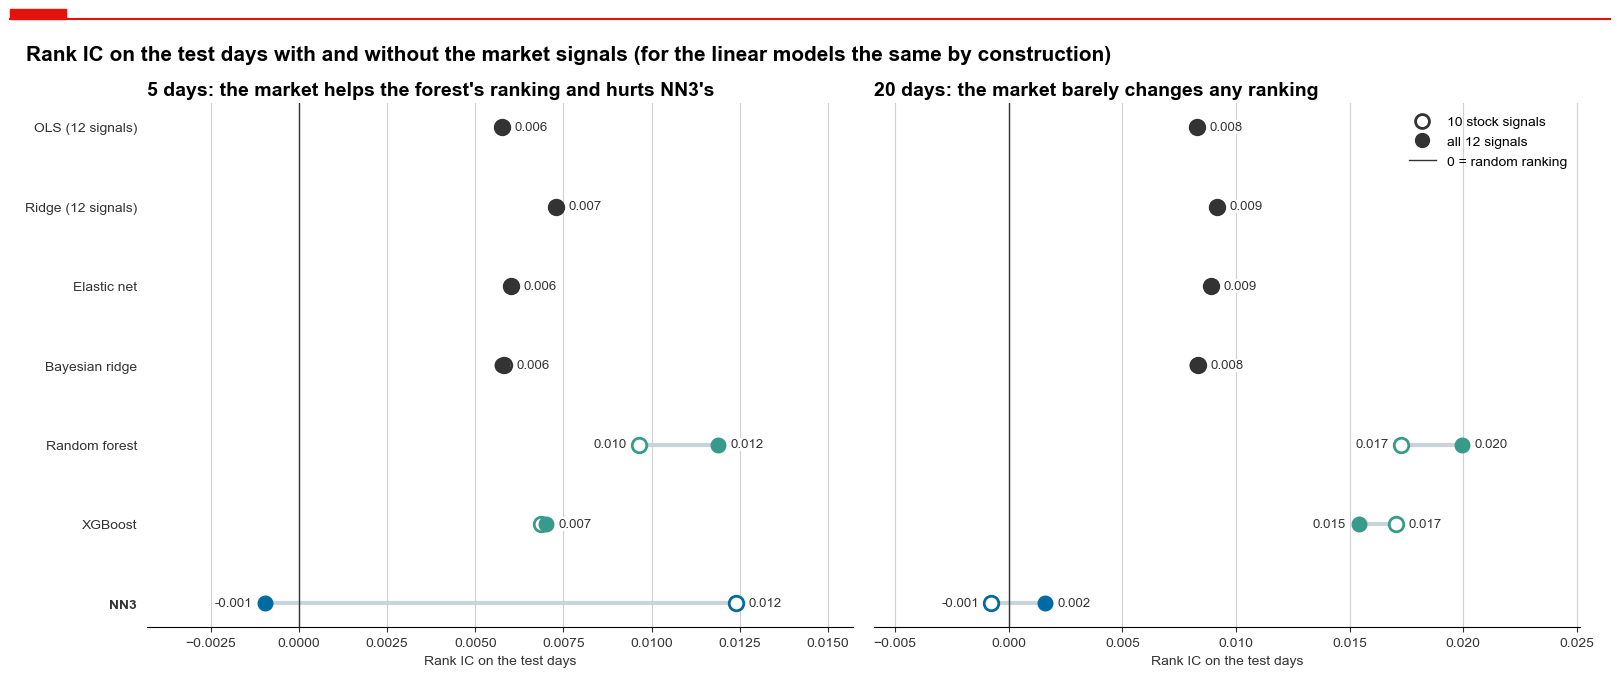

In [17]:
def test_rank_ic(h, source):
    '''Every model's rank IC on the test days.'''
    X, y, masks = data[h]
    test = masks["test"]
    return pd.Series({model: rank_ic(y[test], source[h][model], dates[test])[0] for model in MODELS})


def dumbbells(other, other_label, filled_label, titles, suptitle, legend="upper right"):
    '''Every model's test rank IC with the forecasts of 3.3 (filled dots) and with other forecasts (hollow dots), per horizon.'''
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
    for ax, h in zip(axes, HORIZONS):
        filled, hollow = test_rank_ic(h, forecasts), test_rank_ic(h, other)
        for i, model in enumerate(MODELS):
            ax.plot([hollow[model], filled[model]], [i, i], color=LIGHT_GREY, lw=3, zorder=1)
            ax.scatter(hollow[model], i, s=110, facecolors="white", edgecolors=MODEL_COLORS[model], linewidths=2, zorder=3)
            ax.scatter(filled[model], i, s=110, color=MODEL_COLORS[model], zorder=3)
            left, right = sorted([hollow[model], filled[model]])
            pairs = [(right, 1)] if right - left < 0.0005 else [(left, -1), (right, 1)]     # one label if the dots coincide
            for value, side in pairs:
                ax.annotate(f"{value:.3f}", (value, i), xytext=(9 * side, 0), textcoords="offset points", ha="left" if side > 0 else "right",
                            va="center", fontsize=9.5, color="#333333", bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5})
        ax.axvline(0, color="#333333", lw=1)
        ax.margins(x=0.25)
        ax.set_title(titles[h])
        ax.set_xlabel("Rank IC on the test days")
        ax.grid(False, axis="y")
        ax.grid(True, axis="x", color="#D0D0D0")
    axes[0].set_yticks(np.arange(len(MODELS)), MODELS)
    axes[0].invert_yaxis()
    for label in axes[0].get_yticklabels():
        label.set_fontweight("bold" if label.get_text() == "NN3" else "normal")
    axes[1].legend(handles=[plt.Line2D([], [], marker="o", ls="", markerfacecolor="white", markeredgecolor="#333333", markeredgewidth=2, ms=10,
                                       label=other_label),
                            plt.Line2D([], [], marker="o", ls="", color="#333333", ms=10, label=filled_label),
                            plt.Line2D([], [], color="#333333", lw=1, label="0 = random ranking")], loc=legend, fontsize=10)
    fig.suptitle(suptitle, x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


dumbbells(stock_forecasts, "10 stock signals", "all 12 signals",
          {5: "5 days: the market helps the forest's ranking and hurts NN3's", 20: "20 days: the market barely changes any ranking"},
          "Rank IC on the test days with and without the market signals (for the linear models the same by construction)")

**Main point.** The models hardly need the market signals: with them only the forest ranks a little better at both horizons, while NN3 ranks clearly worse at 5 days.

### 3.5 Would re-estimating every year help?
Gu et al. (2020) re-estimate their models every year, with one more year of training days and the validation days moved forward. We do the same at the start of 2019 and of 2020, but keep the settings of 3.2, so that only the data change: the validation days keep their length and end $h$ days before the new year, the estimation days run up to them, and the networks again keep the epoch with the best validation rank IC. Until the end of 2018 the forecasts stay those of 3.2. The re-estimation of the forest, XGBoost and NN3 takes about 10 minutes, so it is stored on disk like 3.2.

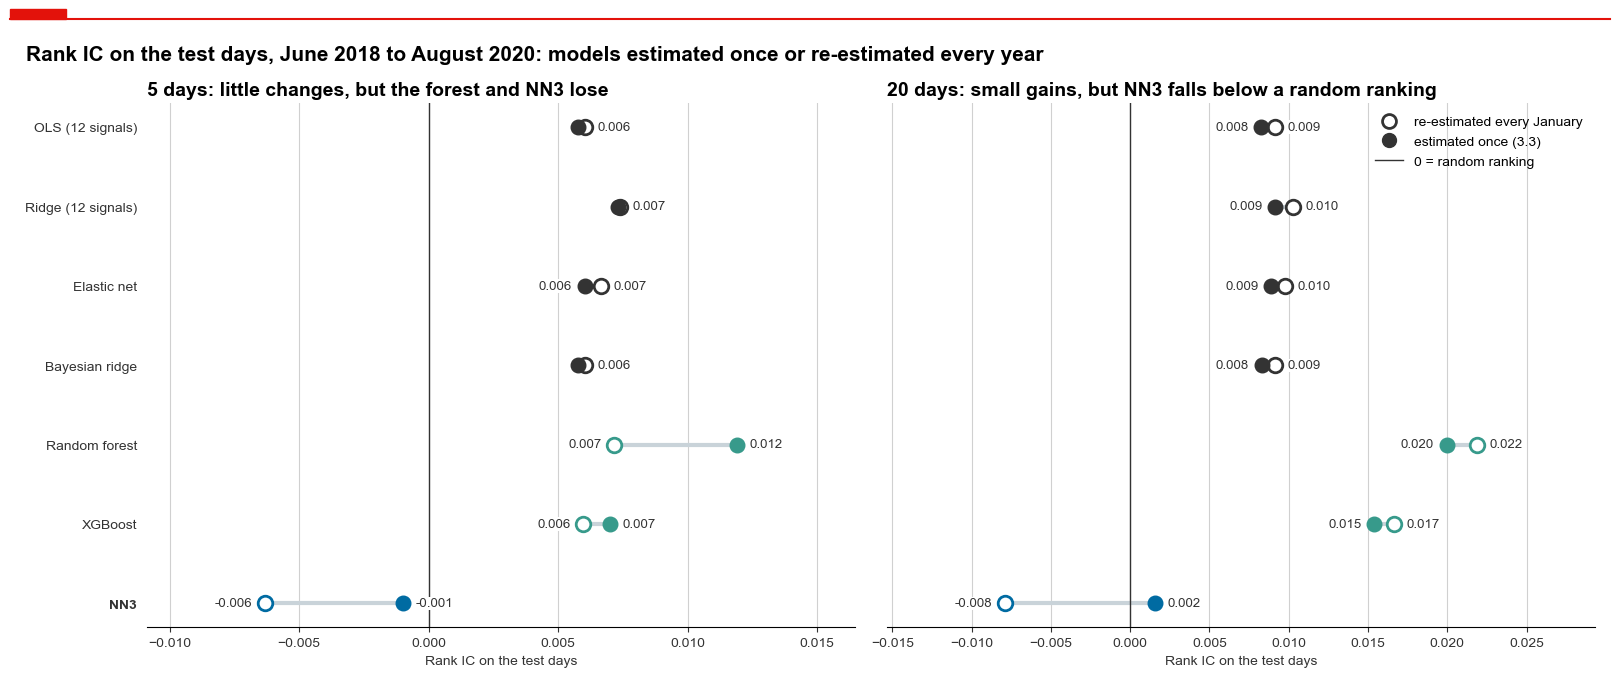

Rank IC of the test days by year, average of the seven models: estimated once -> re-estimated every January


 5 days: 2018 -0.011 | 2019 0.027 -> 0.029 | 2020 -0.015 -> -0.023


20 days: 2018 -0.043 | 2019 0.060 -> 0.059 | 2020 -0.031 -> -0.030


In [18]:
YEARLY_CACHE = "pclab4_yearly_forecasts.npz"
REFIT_YEARS = [2019, 2020]                       # each later test year starts with a re-estimation


def yearly_masks(h, year):
    '''Estimation and validation days of the re-estimation at the start of `year`; the validation days keep their length (2.2).'''
    t = trading_days.searchsorted(pd.Timestamp(year, 1, 1))                 # the year's first trading day
    n_valid = int(int(len(trading_days) * TRAIN_SHARE) * VALID_SHARE)
    observed = ~np.isnan(data[h][1])
    return {"estimation": dates.isin(trading_days[:t - n_valid - h]) & observed,
            "validation": dates.isin(trading_days[t - n_valid:t - h]) & observed}


def train_yearly():
    '''Re-estimate the forest, XGBoost and NN3 at the start of every year of REFIT_YEARS with the settings of 3.2; return their forecasts of that year.'''
    out = {}
    for h, (X, y, masks) in data.items():
        forest_grid, nn3_grid = ml[f"forest_grid_{h}"], ml[f"nn3_grid_{h}"]
        (n, share), (l1, lr) = forest_grid[forest_grid[:, 2].argmax(), :2], nn3_grid[nn3_grid[:, 2].argmax(), :2]
        depth, rate, trees = ml[f"xgb_settings_{h}"]
        for year in REFIT_YEARS:
            refit_masks = yearly_masks(h, year)
            estimation, validation = refit_masks["estimation"], refit_masks["validation"]
            forest = fit_forest(X, y, refit_masks, leaves=[int(n)], shares=[share])[0]
            booster = xgb.XGBRegressor(n_estimators=int(trees), max_depth=int(depth), learning_rate=rate, tree_method="hist",
                                       random_state=SEED).fit(X.loc[estimation, ALL_SIGNALS], y[estimation])
            networks = train_networks(nn3, X.loc[estimation, ALL_SIGNALS], y[estimation], X.loc[validation, ALL_SIGNALS], y[validation],
                                      dates[validation], lr=lr, l1=l1)
            days = masks["test"] & (dates.year == year)
            for key, model in [("forest", forest.predict), ("xgb", booster.predict), ("nn3", lambda Z: predict(networks, Z))]:
                out[f"{key}_{h}_{year}"] = model(X.loc[days, ALL_SIGNALS])
    return out


yearly = cached_forecasts(train_yearly, YEARLY_CACHE)
yearly_forecasts = {h: {} for h in HORIZONS}
for h, (X, y, masks) in data.items():
    test = masks["test"]
    for model in MODELS:
        combined = forecasts[h][model].copy()                                # until the end of 2018: the forecasts of 3.2
        for year in REFIT_YEARS:
            days = dates.year == year
            if model in ML_KEYS:
                combined[days[test]] = yearly[f"{ML_KEYS[model]}_{h}_{year}"]
            else:                                                            # the linear models take seconds: fitted on every run
                refitted = refit(linear_models[h][model], X, y, yearly_masks(h, year), ALL_SIGNALS)
                combined[days[test]] = refitted.predict(X.loc[test & days, ALL_SIGNALS])
        yearly_forecasts[h][model] = combined

dumbbells(yearly_forecasts, "re-estimated every January", "estimated once (3.3)", {5: "5 days: little changes, but the forest and NN3 lose", 20: "20 days: small gains, but NN3 falls below a random ranking"},
          "Rank IC on the test days, June 2018 to August 2020: models estimated once or re-estimated every year")

print("Rank IC of the test days by year, average of the seven models: estimated once -> re-estimated every January")
for h, (X, y, masks) in data.items():
    test = masks["test"]
    by_year = {}
    for name, source in [("once", forecasts), ("every year", yearly_forecasts)]:
        daily = pd.concat([daily_rank_ic(y[test], source[h][model], dates[test]) for model in MODELS], axis=1).mean(axis=1)
        by_year[name] = daily.groupby(daily.index.year).mean()
    once, every_year = by_year["once"], by_year["every year"]
    print(f"{h:>2} days: 2018 {once[2018]:.3f} | " + " | ".join(f"{year} {once[year]:.3f} -> {every_year[year]:.3f}" for year in REFIT_YEARS))

**Comments – Task #3**

**Comment 1 – Which method performs best? None ranks stocks well; the forest does least badly.**
- **On the test days the forest ranks best** (rank IC 0.012 at 5 days, 0.020 at 20 days), XGBoost follows at 20 days (0.015), the linear models stay below 0.01, and NN3 ranks no better than chance (−0.001 and 0.002). All are unstable (ICIR of 0.08 at most), and none reaches the four base signals of Task #2 (0.028 and 0.024).
- **The validation days pointed the other way** (3.3): there NN3 ranked best at both horizons (0.042 and 0.082), as Gu et al. would expect, and every model ranked far better than on the test days, the forest least so. What the calm days of 2017-18 rewarded carried over poorly to 2018-20.
- **Tuning on the rank IC** picks NN3's smallest penalty and a learning rate of 0.01 at both horizons, small trees for the forest (32 and 8 leaves, a quarter of the signals at each split), and an XGBoost of 500 trees at both horizons that splits on 12 and 11 of the 12 signals. It matches the choice to what we evaluate, but one short validation period makes it noisy: the model it rated highest ranked worst on the test days at both horizons.

**Why does NN3 rank so poorly? Probably its flexibility goes into the market, not into the stocks.** A network can bend its response to extreme market moves such as the COVID crash and rebound, which the calm estimation years barely contain; that times the market's level but ranks no stock. 3.4 shows it: with the market signals NN3 ranks worse at 5 days (−0.001 against 0.012 without), while XGBoost barely changes (0.007 either way). The forest gains a little from the market at both horizons (0.010 to 0.012 and 0.017 to 0.020), the interaction 2 bis asked for.

**Would re-estimating every year help? No** (3.5). Most models change by at most 0.002, and the forest at 5 days (0.012 to 0.007) and NN3 at both horizons (−0.001 to −0.006 and 0.002 to −0.008) lose. The year matters far more than the estimation: on average the seven models rank well in 2019 (0.027 and 0.060) and worse than chance in 2018 and 2020 (down to −0.043), a swing that re-estimating on past data cannot anticipate.

**Comparable with Gu et al.?** Hardly: they find networks best in both $R^2_{OOS}$ and portfolio returns, with 920 signals for nearly 30,000 stocks and 30 test years; we have 12 price and volume signals of 481 large stocks and 2.2 test years with one crash.

**Comment 2 – What about Jiang et al. (2023)?** Their network reads images of 20 days of prices and volumes and finds strong weekly predictability across all US stocks (a long-short Sharpe ratio of 7.2), but much less among the 500 largest (0.78, their Table IV). We use their information set and one of their patterns, the range position, not their network: among large stocks their own results leave little to find, and our rank ICs confirm that prices and volumes say little about which large stock will beat which.

## Task #4 – Performance of the ML-driven portfolio
Our ML model is chosen like every setting before it: by the rank IC on the validation days. That is **NN3** at both horizons (3.3), also Gu et al.'s best model. The forest ranks best on the test days, but choosing by the test period's results would be hindsight; the Conclusion shows what every model's portfolio would have earned. From the first test day (20 June 2018), every $h$ days we buy in equal weights the 10 S&P 500 stocks with the highest forecast and hold them for $h$ days; with about 470 stocks instead of the lab's eight, 10 spread the bet better than the slides' 4. One function, `simulate`, values the ML and the random portfolios alike: positions drift with prices, and each rebalancing pays the fee on the amount traded, as in the slides' example (selling \$50 of A to buy \$50 of B costs 1 bp of \$50). Sharpe ratios are annualised with a zero risk-free rate, as in PC Labs #1 and #2.

In [19]:
K = 10                  # stocks per side of the S&P 500 portfolios
N_SIM = 1_000           # random portfolios in the Monte Carlo benchmarks
FEE = 1e-4              # 1 basis point of every amount traded


def simulate(weights, prices, fee=0.0, start=100.0):
    '''
    Daily values of S portfolios. weights: list of (rebalancing day, S x N target weights, negative = short).
    Positions drift with prices between rebalancing days; each rebalancing pays fee x the amount traded.
    Returns the values (days x S).
    '''
    days = [day for day, _ in weights] + [prices.index[-1]]
    value, held = np.full(len(weights[0][1]), start), np.zeros_like(weights[0][1])
    paths = []
    for (day, target), end in zip(weights, days[1:]):
        turnover = 0.5 * (np.abs(target - held).sum(axis=1) + np.abs(target.sum(axis=1) - held.sum(axis=1)))   # stocks and cash
        value = value * (1 - fee * turnover)
        relative = np.nan_to_num((prices.loc[day:end] / prices.loc[day]).to_numpy(), nan=1.0)                # price relatives
        path = value[:, None] * (1 + (relative - 1) @ target.T).T
        held = target * relative[-1] * (value / path[:, -1])[:, None]                                        # weights drifted to the end
        value = path[:, -1]
        paths.append(path if end == days[-1] else path[:, :-1])
    return pd.DataFrame(np.concatenate(paths, axis=1).T, index=prices.loc[days[0]:].index)


def ml_weights(forecast, h, k=K, side="long", eligible=None):
    '''Every h days, among the eligible stocks: 1/k on the k highest forecasts (long), -1/k on the k lowest (short), or both (long-short).'''
    forecast = forecast.unstack("ticker").reindex(columns=close_filled.columns)
    if eligible is not None:
        forecast = forecast.where(eligible)
    weights = []
    for day in forecast.index[::h]:
        ranked = forecast.loc[day].dropna().sort_values()
        target = pd.Series(0.0, index=forecast.columns)
        if side in ("long", "long-short"):
            target[ranked.index[-k:]] = 1 / k
        if side in ("short", "long-short"):
            target[ranked.index[:k]] = -1 / k
        weights.append((day, target.to_numpy()[None, :]))
    return weights


def random_weights(days, available, k=K, side="long", random_size=False, n=N_SIM, seed=SEED):
    '''n portfolios of k random stocks on each day, held long, short or both (k of each), in equal weights
    or in random weights (uniform draws rescaled to sum to one, as in PC Lab #1).'''
    signs = {"long": [1], "short": [-1], "long-short": [1, -1]}[side]
    rng = np.random.default_rng(seed)
    weights = []
    for day in days:
        pool = np.flatnonzero(available.loc[day].to_numpy())
        target = np.zeros((n, available.shape[1]), dtype=np.float32)
        for row in target:
            picks = rng.choice(pool, k * len(signs), replace=False)
            for j, sign in enumerate(signs):
                size = rng.random(k) if random_size else np.ones(k)
                row[picks[j * k:(j + 1) * k]] = sign * size / max(size.sum(), 1e-12)
        weights.append((day, target))
    return weights


def sharpe_ratio(values):
    '''Annualised Sharpe ratio of every column of daily values (risk-free rate 0).'''
    daily = values.pct_change(fill_method=None).dropna()
    return daily.mean() / daily.std() * np.sqrt(DAYS)


def test_forecast(h, model="NN3"):
    '''Test forecasts of a model as a Series indexed by (date, ticker).'''
    return pd.Series(forecasts[h][model], index=panel.index[data[h][2]["test"]])


close_filled = close.ffill()                                        # carry the last price over the rare missing days

### 4.1 Long, short and long-short against 1,000 random portfolios
Three portfolios, rebalanced every $h$ days: **long**, the 10 highest forecasts; **short**, a bet against the 10 lowest, the \$100 backing the short sale; **long-short**, both at once, a bet on the ranking alone. Two Monte Carlo benchmarks of 1,000 draws each: **random buy-and-hold** (the slides'), 10 random stocks with random weights (sold short, or 10 of each, for the other portfolios) bought on the first test day, and **random picks**, the ML procedure with a random ranking, which isolates the forecast. The figure shows \$100 in the long portfolios (left) and every Sharpe ratio against the 5%-95% range of both benchmarks (right; label: the share of random buy-and-hold | random picks it beats). Below it: the slides' 1 bp fees against the 10 bp Jiang et al. (2023) charge for large stocks, the average 20-day return of ten groups of stocks sorted by NN3's forecast each day, and a survivorship check among the larger half of the stocks by dollar volume, which excludes most companies that joined the index later because they did well.

In [20]:
SIDES = {"long top 10": "long", "short bottom 10": "short", "long-short 10/10": "long-short"}


def sp500_strategies(h, model="NN3", eligible=None):
    '''ML long, short and long-short portfolios for one horizon, their fees and the two Monte Carlo benchmarks.'''
    forecast = test_forecast(h, model)
    first = forecast.index.get_level_values("date")[0]
    prices = close_filled.loc[first:]
    available = forecast.unstack("ticker").reindex(columns=prices.columns).notna()
    if eligible is not None:
        available &= eligible.reindex(index=available.index, columns=available.columns, fill_value=False)
    rebalancing = available.index[::h]
    out = {}
    for name, side in SIDES.items():
        ml_values = {fee: simulate(ml_weights(forecast, h, side=side, eligible=available), prices, fee)[0] for fee in [0, FEE, 10 * FEE]}
        buy_and_hold = simulate(random_weights([first], available, side=side, random_size=True), prices, FEE)
        random_picks = simulate(random_weights(rebalancing, available, side=side), prices, FEE)
        out[name] = {"values": ml_values, "buy and hold": buy_and_hold, "random picks": random_picks}
    return out


def summary_row(strategy):
    '''Final values, Sharpe ratio and Monte Carlo percentiles of one ML strategy.'''
    net = strategy["values"][FEE]
    sharpe = sharpe_ratio(net.to_frame())[0]
    return {"$100 becomes": strategy["values"][0].iloc[-1], "after 1 bp": net.iloc[-1], "after 10 bp": strategy["values"][10 * FEE].iloc[-1],
            "Sharpe (1 bp)": sharpe,
            "Sharpe beats random buy-and-hold": (sharpe_ratio(strategy["buy and hold"]) < sharpe).mean(),
            "Sharpe beats random picks": (sharpe_ratio(strategy["random picks"]) < sharpe).mean()}


strategies = {h: sp500_strategies(h) for h in HORIZONS}
task4 = pd.DataFrame({(f"every {h} days", name): summary_row(strategy) for h, by_name in strategies.items() for name, strategy in by_name.items()}).T

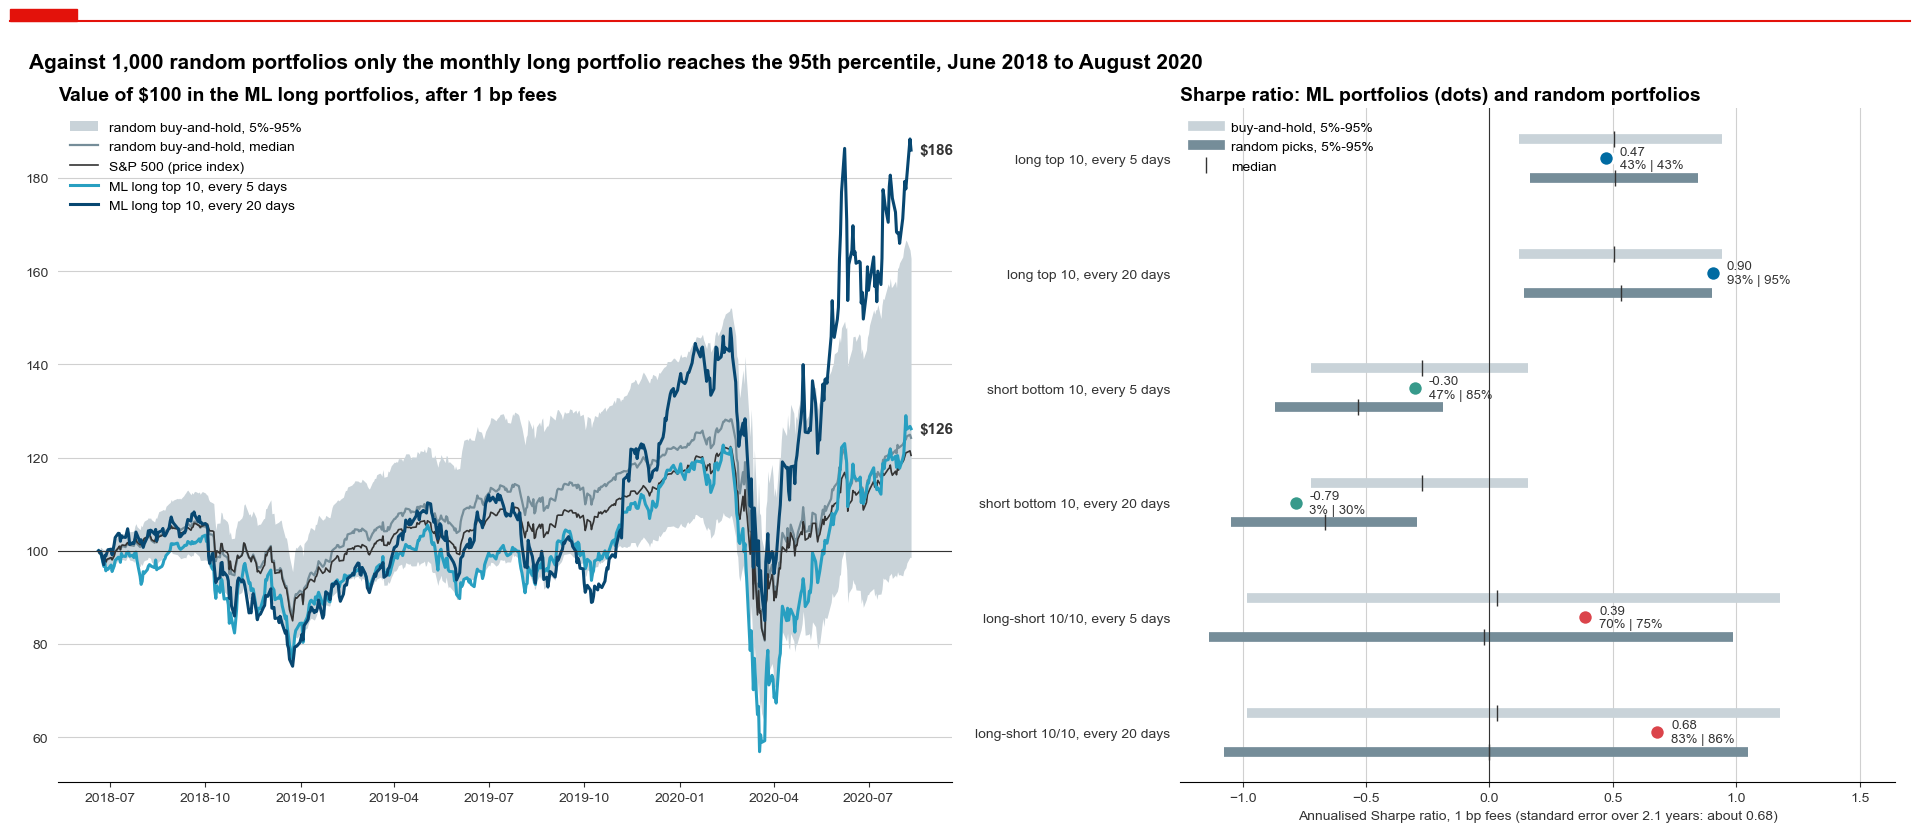

Equal weights on all 467 stocks (1/N, buy-and-hold): $125.92 | S&P 500 price index: $120.47
$100 with no fees | 1 bp | 10 bp, every 5 days: long top 10 $127.02 | $126.18 | $118.87, short bottom 10 $83.78 | $83.14 | $77.60, long-short 10/10 $118.78 | $117.11 | $103.08
$100 with no fees | 1 bp | 10 bp, every 20 days: long top 10 $186.27 | $185.98 | $183.36, short bottom 10 $64.26 | $64.11 | $62.72, long-short 10/10 $146.68 | $146.12 | $141.13
Average 20-day return of NN3's ten forecast groups, lowest to highest (%), all test days: 1.16 1.13 1.15 1.00 0.99 0.98 1.02 1.15 1.26 1.56
Average 20-day return of NN3's ten forecast groups, lowest to highest (%), before COVID: 1.11 1.15 1.23 1.16 1.13 1.19 1.19 1.30 1.22 1.38


In [21]:
first = test_forecast(5).index[0][0]
sp500 = 100 * market_close.loc[first:] / market_close.loc[first]
universe = close_filled.loc[first:, test_forecast(5).xs(first, level="date").index]
equal_weights = 100 * (universe / universe.iloc[0]).mean(axis=1)
band = strategies[5]["long top 10"]["buy and hold"].quantile([0.05, 0.5, 0.95], axis=1).T
STRATEGY_COLORS = {"long top 10": ECONOMIST_COLORS[0], "short bottom 10": ECONOMIST_COLORS[2], "long-short 10/10": ECONOMIST_COLORS[8]}
test_years = len(sp500) / DAYS

X, y, masks = data[20]                                              # NN3's ranking: the realised 20-day return by forecast group
realised = pd.Series(y[masks["test"]], index=panel.index[masks["test"]])
decile = test_forecast(20).groupby(level="date").transform(lambda f: pd.qcut(f.rank(method="first"), 10, labels=False) + 1)
by_decile = realised.groupby([realised.index.get_level_values("date"), decile]).mean().unstack() * 100   # days x forecast groups, in %
before_covid = by_decile.index < COVID[0]

fig, axes = plt.subplots(1, 2, figsize=(19, 8), gridspec_kw={"width_ratios": [1.25, 1]})
axes[0].fill_between(band.index, band[0.05], band[0.95], color=LIGHT_GREY, lw=0, label="random buy-and-hold, 5%-95%")
axes[0].plot(band.index, band[0.5], color=GREY, lw=1.6, label="random buy-and-hold, median")
axes[0].plot(sp500.index, sp500, color="#333333", lw=1.2, label="S&P 500 (price index)")
for h in HORIZONS:
    values = strategies[h]["long top 10"]["values"][FEE]
    axes[0].plot(values.index, values, color=HORIZON_COLORS[h], lw=2.2, label=f"ML long top 10, every {h} days")
    axes[0].annotate(f"${values.iloc[-1]:.0f}", (values.index[-1], values.iloc[-1]), xytext=(6, 0), textcoords="offset points",
                     va="center", fontsize=11, fontweight="bold", color="#333333")
axes[0].axhline(100, color="#333333", lw=0.8)
axes[0].set_title("Value of $100 in the ML long portfolios, after 1 bp fees")
axes[0].legend(loc="upper left", fontsize=10)
axes[0].grid(False, axis="x")

rows = [(name, h) for name in STRATEGY_COLORS for h in HORIZONS]
for i, (name, h) in enumerate(rows):
    strategy = strategies[h][name]
    for offset, key, color in [(-0.17, "buy and hold", LIGHT_GREY), (0.17, "random picks", GREY)]:
        low, middle, high = sharpe_ratio(strategy[key]).quantile([0.05, 0.5, 0.95])
        axes[1].plot([low, high], [i + offset] * 2, color=color, lw=7, solid_capstyle="butt")
        axes[1].plot(middle, i + offset, marker="|", color="#333333", ms=11)
    sharpe = sharpe_ratio(strategy["values"][FEE].to_frame())[0]
    axes[1].scatter(sharpe, i, s=120, color=STRATEGY_COLORS[name], edgecolors="white", linewidths=2, zorder=3)
    beaten = task4.loc[(f"every {h} days", name), ["Sharpe beats random buy-and-hold", "Sharpe beats random picks"]]
    axes[1].annotate(f"{sharpe:.2f}\n{beaten.iloc[0]:.0%} | {beaten.iloc[1]:.0%}", (sharpe, i), xytext=(10, 0), textcoords="offset points",
                     va="center", fontsize=9.5, color="#333333")
axes[1].set_yticks(range(len(rows)), [f"{name}, every {h} days" for name, h in rows])
axes[1].invert_yaxis()
axes[1].axvline(0, color="#333333", lw=0.8)
axes[1].grid(False, axis="y")
axes[1].grid(True, axis="x", color="#D0D0D0")
axes[1].set_xlabel(f"Annualised Sharpe ratio, 1 bp fees (standard error over {test_years:.1f} years: about {1 / np.sqrt(test_years):.2f})")
axes[1].set_title("Sharpe ratio: ML portfolios (dots) and random portfolios")
axes[1].set_xlim(right=axes[1].get_xlim()[1] + 0.35)                                   # room for the labels
axes[1].legend(handles=[plt.Line2D([], [], color=LIGHT_GREY, lw=7, label="buy-and-hold, 5%-95%"),
                        plt.Line2D([], [], color=GREY, lw=7, label="random picks, 5%-95%"),
                        plt.Line2D([], [], color="#333333", marker="|", ls="", ms=11, label="median")],
               loc="upper left", fontsize=10)

fig.suptitle("Against 1,000 random portfolios only the monthly long portfolio reaches the 95th percentile, June 2018 to August 2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

print(f"Equal weights on all {universe.shape[1]} stocks (1/N, buy-and-hold): ${equal_weights.iloc[-1]:.2f} | S&P 500 price index: ${sp500.iloc[-1]:.2f}")
for h in HORIZONS:
    print(f"$100 with no fees | 1 bp | 10 bp, every {h} days: " + ", ".join(
        f"{name} " + " | ".join(f"${task4.loc[(f'every {h} days', name), column]:.2f}" for column in ["$100 becomes", "after 1 bp", "after 10 bp"])
        for name in SIDES))
for label, days in [("all test days", slice(None)), ("before COVID", before_covid)]:
    print(f"Average 20-day return of NN3's ten forecast groups, lowest to highest (%), {label}:", " ".join(f"{value:.2f}" for value in by_decile.loc[days].mean()))

In [22]:
large_half = (close * volume).rolling(20).mean().rank(axis=1, pct=True) > 0.5      # larger half by 20-day dollar volume, known each day
print("Survivorship check, the strategies among the larger half of the stocks: Sharpe ratio, 1 bp fees (share of random picks it beats)")
for h in HORIZONS:
    larger = sp500_strategies(h, eligible=large_half)
    print(f"  every {h} days: " + ", ".join(f"{name} {row['Sharpe (1 bp)']:.2f} ({row['Sharpe beats random picks']:.1%})"
                                         for name, row in ((name, summary_row(larger[name])) for name in SIDES)))

Survivorship check, the strategies among the larger half of the stocks: Sharpe ratio, 1 bp fees (share of random picks it beats)


  every 5 days: long top 10 0.68 (84.1%), short bottom 10 0.04 (99.6%), long-short 10/10 0.83 (92.7%)


  every 20 days: long top 10 0.40 (33.1%), short bottom 10 -0.94 (6.1%), long-short 10/10 0.05 (52.4%)


**Comments – 4.1**

- **\$100 become** \$126.18 and \$185.98 in the long portfolios (rebalanced every 5 and 20 days, after 1 bp fees), \$83.14 and \$64.11 in the short ones and \$117.11 and \$146.12 in the long-short ones, against \$125.92 for 1/N and \$120.47 for the S&P 500. Fees of 1 bp cost at most \$1.67; at 10 bp, Jiang et al.'s cost for large stocks, the weekly long-short portfolio keeps \$103.08.
- **Only the monthly long portfolio reaches the edge of chance** (right): with a Sharpe ratio of 0.90 it beats 95.1% of the random picks; the other long and long-short portfolios (0.39 to 0.68) beat 43.3% to 86.5% of the random portfolios. One result at the 95th percentile among six strategies is what chance produces about one time in four, and over 2.1 years a Sharpe ratio has a standard error of about 0.68 (Lo, 2002). The survivorship check points the same way: among the larger half of the stocks the monthly long portfolio falls to 0.40 (33.1% of the random picks), while the weekly ones improve (0.68 and 0.83).
- **NN3's ranking is weak (3.3):** sorted into ten groups by its 20-day forecast, the stocks it liked most earned 1.56% over the next 20 days and those it liked least 1.16%, about as much as groups 2, 3 and 8. The short portfolios lose money, as shorting in a rising market tends to; the monthly one beats only 3.1% of the random buy-and-hold shorts.

### 4.2 Is the ML portfolio more than a beta bet?
High-beta stocks rebound most after a crash, so the ML portfolios may simply buy beta. Two tests:
- **Two one-line rules** with the same rebalancing and fees: **beta**, the 10 highest-beta stocks (the 10 lowest on the short side), and **beta timing**, high-beta stocks after the S&P 500 fell over the past 20 days and low-beta stocks after it rose.
- **Factor regressions** as in Gu et al. (2020, Table 8): daily returns (in excess of the risk-free rate for the long portfolios; the others finance themselves) on the five Fama-French factors, momentum and short-term reversal, with Newey-West standard errors. The alpha is what the seven factors leave unexplained.

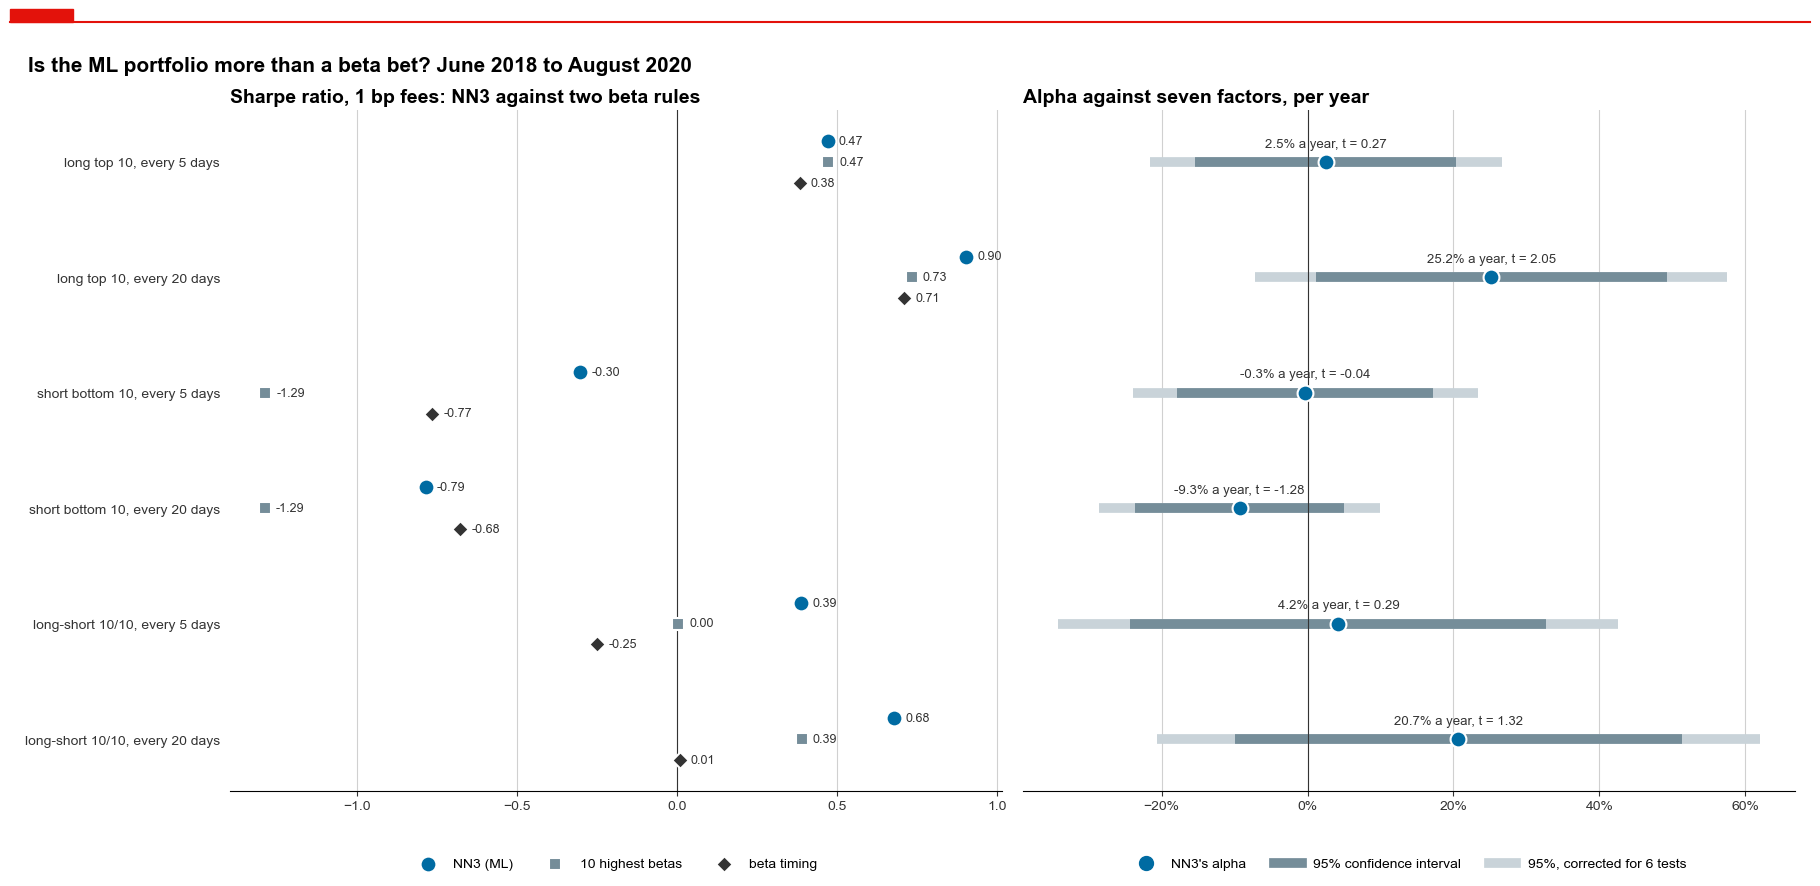

NN3's top 10 that are also among the 10 highest betas, on average: {'every 5 days': 1.4, 'every 20 days': 1.2}
Monthly portfolios against the seven factors: long top 10 R2 0.83 (Mkt-RF +1.20, SMB +0.42, Mom -0.62) | short bottom 10 R2 0.70 (Mkt-RF -0.80, CMA -0.92) | long-short 10/10 R2 0.58 (SMB +0.56, CMA -1.05, Mom -1.06)


In [23]:
def daily_factors(cache="ff_daily_factors_2011-01-01_to_2020-08-11.csv"):
    '''Daily Fama-French five factors, momentum and short-term reversal (Ken French's data library), in decimals, cached on disk.'''
    if not os.path.exists(cache):
        import io, zipfile, requests
        frames = []
        for name in ["F-F_Research_Data_5_Factors_2x3_daily", "F-F_Momentum_Factor_daily", "F-F_ST_Reversal_Factor_daily"]:
            url = f"https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{name}_CSV.zip"
            reply = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (Bocconi 20598 PC Lab, academic use)"}, timeout=60)
            lines = zipfile.ZipFile(io.BytesIO(reply.content)).read(name + ".csv").decode("latin-1").splitlines()
            start = next(i for i, line in enumerate(lines) if line.startswith(","))      # the header of the daily table
            end = next(i for i in range(start + 1, len(lines)) if not lines[i].strip())
            frames.append(pd.read_csv(io.StringIO("\n".join(lines[start:end])), index_col=0))
        factors = pd.concat(frames, axis=1, join="inner").sort_index()                  # the days all three files cover
        factors.index = pd.to_datetime(factors.index.astype(str), format="%Y%m%d")
        (factors.loc[DOWNLOAD_START:SAMPLE_END] / 100).round(6).to_csv(cache)
    return pd.read_csv(cache, index_col=0, parse_dates=True)


def beta_forecast(h, timing=False):
    '''A stock's beta used as its forecast on the test days of horizon h; with timing, minus beta after the S&P 500 rose over 20 days.'''
    test = data[h][2]["test"]
    beta = panel.loc[test, "beta"]
    return beta.where(panel.loc[test, "market 20d"] < 0, -beta) if timing else beta


FACTORS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "ST_Rev"]
factors = daily_factors()
bets, regressions, overlap = {}, {}, {}
for h in HORIZONS:
    prices = close_filled.loc[test_forecast(h).index[0][0]:]
    candidates = {"NN3": test_forecast(h), "beta": beta_forecast(h), "beta timing": beta_forecast(h, timing=True)}
    for side, direction in SIDES.items():
        for name, forecast in candidates.items():
            values = simulate(ml_weights(forecast, h, side=direction), prices, FEE)[0]
            bets.setdefault((side, name), {}).update({(f"every {h} days", "$100 becomes"): values.iloc[-1],
                                                      (f"every {h} days", "Sharpe"): sharpe_ratio(values.to_frame())[0]})
        daily = strategies[h][side]["values"][FEE].pct_change().dropna()
        excess = daily - factors.loc[daily.index, "RF"] if direction == "long" else daily    # short positions finance themselves
        lags = int(4 * (len(daily) / 100) ** (2 / 9))                                      # lag rule of PC Lab #2
        capm, seven = (ols(excess, factors.loc[daily.index, columns], hac_lags=lags) for columns in (["Mkt-RF"], FACTORS))
        regressions[(f"every {h} days", side)] = {"CAPM alpha p.a.": capm.params[0] * DAYS, "t(CAPM alpha)": capm.tvalues[0],
                                                  "alpha p.a.": seven.params[0] * DAYS, "t(alpha)": seven.tvalues[0],
                                                  **dict(zip(FACTORS, seven.params[1:])), "R2": seven.rsquared}
    nn3_picks, beta_picks = ml_weights(test_forecast(h), h), ml_weights(beta_forecast(h), h)
    overlap[f"every {h} days"] = np.mean([((a > 0) & (b > 0)).sum() for (_, a), (_, b) in zip(nn3_picks, beta_picks)])

bets, regressions = pd.DataFrame(bets).T, pd.DataFrame(regressions).T
rows = [(side, h) for side in SIDES for h in HORIZONS]
z, z_corrected = norm.ppf(0.975), norm.ppf(1 - 0.025 / len(rows))   # 95%, and 95% corrected for the number of strategies (Bonferroni)
fig, axes = plt.subplots(1, 2, figsize=(18, 8.5))
axes[1].sharey(axes[0])
for name, label, marker, color, size, offset in [("NN3", "NN3 (ML)", "o", ECONOMIST_COLORS[0], 130, -0.18),
                                                  ("beta", "10 highest betas", "s", GREY, 80, 0.0),
                                                  ("beta timing", "beta timing", "D", "#333333", 70, 0.18)]:
    sharpes = [bets.loc[(side, name), (f"every {h} days", "Sharpe")] for side, h in rows]
    axes[0].scatter(sharpes, np.arange(len(rows)) + offset, marker=marker, s=size, color=color, edgecolors="white", linewidths=1.5, zorder=3, label=label)
    for x, position in zip(sharpes, np.arange(len(rows)) + offset):
        axes[0].annotate(f"{x:.2f}", (x, position), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color="#333333")
for i, (side, h) in enumerate(rows):
    alpha, t = regressions.loc[(f"every {h} days", side), ["alpha p.a.", "t(alpha)"]]
    for width, color in [(z_corrected, LIGHT_GREY), (z, GREY)]:
        axes[1].plot([alpha - width * alpha / t, alpha + width * alpha / t], [i, i], color=color, lw=7, solid_capstyle="butt")
    axes[1].scatter(alpha, i, s=130, color=ECONOMIST_COLORS[0], edgecolors="white", linewidths=1.5, zorder=3)
    axes[1].annotate(f"{alpha:.1%} a year, t = {t:.2f}", (alpha, i), xytext=(0, 11), textcoords="offset points", ha="center", fontsize=9.5, color="#333333")
axes[0].set_yticks(range(len(rows)), [f"{side}, every {h} days" for side, h in rows])
axes[0].invert_yaxis()
axes[0].set_title("Sharpe ratio, 1 bp fees: NN3 against two beta rules")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10)
axes[1].set_title("Alpha against seven factors, per year")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axes[1].legend(handles=[plt.Line2D([], [], color=ECONOMIST_COLORS[0], marker="o", ls="", ms=10, label="NN3's alpha"),
                        plt.Line2D([], [], color=GREY, lw=7, label="95% confidence interval"),
                        plt.Line2D([], [], color=LIGHT_GREY, lw=7, label=f"95%, corrected for {len(rows)} tests")],
               loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10)
axes[1].tick_params(axis="y", labelleft=False)
for ax in axes:
    ax.axvline(0, color="#333333", lw=0.8)
    ax.grid(False, axis="y")
    ax.grid(True, axis="x", color="#D0D0D0")
fig.suptitle("Is the ML portfolio more than a beta bet? June 2018 to August 2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

print("NN3's top 10 that are also among the 10 highest betas, on average:", {h: round(n, 1) for h, n in overlap.items()})
monthly = regressions.xs("every 20 days", level=0).astype(float)
print("Monthly portfolios against the seven factors: " + " | ".join(
    f"{side} R2 {row['R2']:.2f} (" + ", ".join(f"{factor} {row[factor]:+.2f}" for factor in FACTORS if abs(row[factor]) >= 0.4) + ")"
    for side, row in monthly.iterrows()))

**Comments – 4.2**

- **NN3 beats both beta rules in four of the six portfolios** (left): every month its long portfolio reaches a Sharpe ratio of 0.90 against 0.73 for the 10 highest betas and 0.71 for beta timing, and its long-short portfolio 0.68 against 0.39 and 0.01; every week its short (−0.30 against −1.29 and −0.77) and long-short portfolios (0.39 against 0.00 and −0.25) do better too. Its top 10 hold only 1.4 and 1.2 of the 10 highest betas on average.
- **No significant positive alpha against seven factors** (right): the monthly long portfolio earns 25.2% a year more than its factor exposures explain ($t$ = 2.05), significant on its own but not after correcting for six tests (critical value 2.6); the other alphas lie between −9.3% and 20.7% a year ($t$ = −1.28 to 1.32). Gu et al.'s network portfolios keep large, significant alphas (their Table 8); ours do not.
- **Mostly known factor bets:** the seven factors explain 83%, 70% and 58% of the daily variance of the monthly long, short and long-short portfolios; the long one loads 1.20 on the market.

## Conclusion
All models in one figure: their ranking skill, the rank IC on the test days (further right = better), and the economic measure, the Sharpe ratio of the long-short portfolio of Task #4 (10 best minus 10 worst forecasts, rebalanced every $h$ days, 1 bp fees; higher = better). The vertical line marks a random ranking, the dashed line the 95th percentile of the 1,000 random long-short portfolios of 4.1.

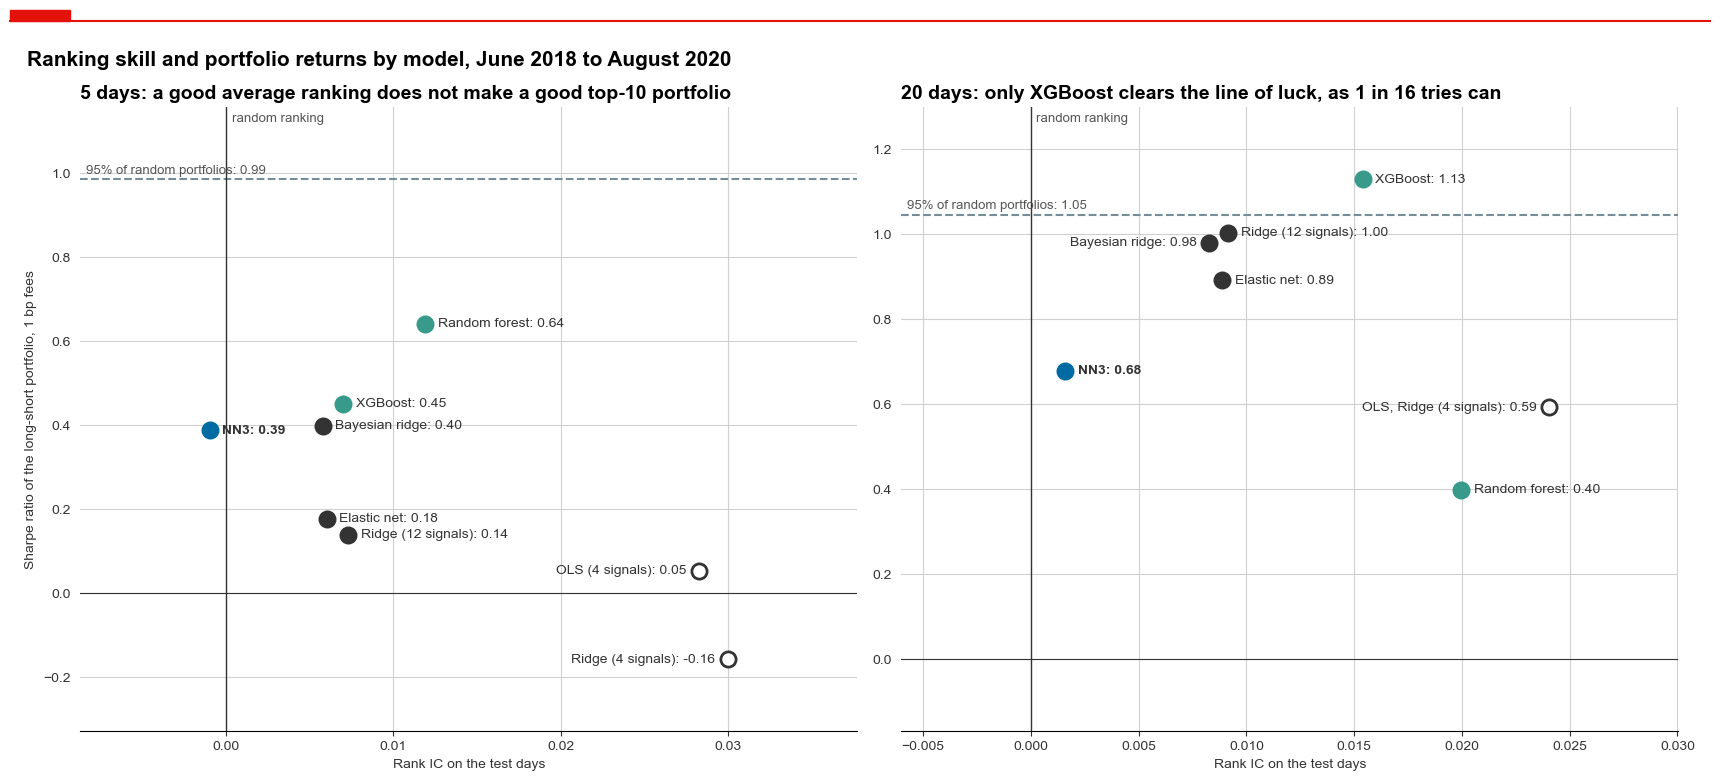

In [24]:
FINAL_MODELS = ["OLS (4 signals)", "Ridge (4 signals)", "Ridge (12 signals)", "Elastic net", "Bayesian ridge", "Random forest", "XGBoost", "NN3"]
summary = {}
for h, (X, y, masks) in data.items():
    test = masks["test"]
    prices = close_filled.loc[test_forecast(h).index[0][0]:]
    for model in FINAL_MODELS:
        long_short = simulate(ml_weights(test_forecast(h, model), h, side="long-short"), prices, FEE)
        summary[(h, model)] = {"rank IC": rank_ic(y[test], forecasts[h][model], dates[test])[0], "long-short Sharpe": sharpe_ratio(long_short)[0]}
summary = pd.DataFrame(summary).T
random_95 = {h: sharpe_ratio(strategies[h]["long-short 10/10"]["random picks"]).quantile(0.95) for h in HORIZONS}   # 4.1's random picks

LABEL_OFFSETS = {(5, "OLS (4 signals)"): (-9, 0), (5, "Ridge (4 signals)"): (-9, 0), (20, "OLS (4 signals)"): (-9, 0), (20, "Bayesian ridge"): (-9, 0)}                                                          # (horizon, first model): (dx, dy) in points, where labels would overlap


def dot_label(names):
    '''One label for models whose forecasts coincide, such as OLS and Ridge on the four base signals.'''
    if len(names) > 1 and all(name.endswith("(4 signals)") for name in names):
        return ", ".join(name.replace(" (4 signals)", "") for name in names) + " (4 signals)"
    return ", ".join(names[:2]) + (",\n" + ", ".join(names[2:]) if len(names) > 2 else "")      # long lists on two lines


fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
titles = {5: "5 days: a good average ranking does not make a good top-10 portfolio", 20: "20 days: only XGBoost clears the line of luck, as 1 in 16 tries can"}
for ax, h in zip(axes, HORIZONS):
    part = summary.xs(h, level=0).astype(float)
    ax.axhline(random_95[h], color=GREY, lw=1.5, ls="--")
    ax.axvline(0, color="#333333", lw=1)
    ax.axhline(0, color="#333333", lw=0.8)
    key = pd.Series(list(zip(part["rank IC"].round(3), part["long-short Sharpe"].round(1))), index=part.index)
    for position, names in key.groupby(key).groups.items():                  # models with the same forecasts share one dot
        names = [name for name in FINAL_MODELS if name in names]
        x, sharpe = part.loc[names, "rank IC"].mean(), part.loc[names, "long-short Sharpe"].mean()
        color = MODEL_COLORS.get(names[0], "#333333")
        hollow = names[0].endswith("(4 signals)")                            # the base signals of Task #2
        ax.scatter(x, sharpe, s=120, facecolors="white" if hollow else color, edgecolors=color, linewidths=2, zorder=3)
        dx, dy = LABEL_OFFSETS.get((h, names[0]), (9, 0))
        low, high = part.loc[names, "long-short Sharpe"].min(), part.loc[names, "long-short Sharpe"].max()
        value = f"{low:.2f}" if round(low, 2) == round(high, 2) else f"{low:.2f} to {high:.2f}"
        ax.annotate(f"{dot_label(names)}: {value}", (x, sharpe), xytext=(dx, dy), textcoords="offset points", ha="left" if dx >= 0 else "right",
                    va="center", fontsize=10, color="#333333", fontweight="bold" if "NN3" in names else "normal")
    ax.annotate(f"95% of random portfolios: {random_95[h]:.2f}", (0, random_95[h]), xycoords=("axes fraction", "data"), xytext=(4, 4),
                textcoords="offset points", fontsize=9.5, color="#555555")
    ax.annotate("random ranking", (0, 1), xycoords=("data", "axes fraction"), xytext=(4, -4), textcoords="offset points", va="top",
                fontsize=9.5, color="#555555")
    ax.set_xlabel("Rank IC on the test days")
    ax.set_title(titles[h])
    ax.margins(x=0.25, y=0.15)
    ax.grid(True, axis="x", color="#D0D0D0")
axes[0].set_ylabel("Sharpe ratio of the long-short portfolio, 1 bp fees")
fig.suptitle("Ranking skill and portfolio returns by model, June 2018 to August 2020",
             x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**The questions of the slides, answered.**
- **Returns and volume changes** (1.2): volume rises with the size of the return, barely with its sign, and does not predict the next day's return.
- **$R^2_{OOS}$ of OLS and Ridge on the four base signals** (2.4): 0.30% and 0.29% at 5 days, 0.99% for both at 20 days; 88% and 97% of it is the average return.
- **Is $R^2_{OOS}$ a good metric?** To rank forecasts on the same test days, yes; as evidence of skill, no: its zero benchmark lets the average return pass for skill, and a few volatile weeks and the size of the forecasts dominate it. We therefore benchmark with the rank IC, the ranking of stocks a portfolio needs, and with the Sharpe ratio (figure). The two often disagree: at 5 days the best rankers, OLS and Ridge on the four base signals, build the worst long-short portfolios (0.05 and −0.16), and at 20 days XGBoost's portfolio (1.13) is the only one to clear the 95th percentile of the random portfolios (1.05), one of 16 tries.
- **The market and more signals** (2 bis, 3.4): the market cannot change a linear model's ranking and barely changes the others'; the extra stock signals help on the validation days and hurt on the test days.
- **Best machine learning method** (Task #3): by ranking, the forest (rank IC 0.012 and 0.020), though none beats the four base signals of Task #2; NN3, Gu et al.'s best, ranks no better than chance.
- **\$100 in the ML portfolio** (4.1), after 1 bp fees, rebalanced every 5 and 20 days: \$126.18 and \$185.98 long, \$83.14 and \$64.11 short, \$117.11 and \$146.12 long-short; the fees cost at most \$1.67.
- **Against 1,000 random portfolios** (4.1): only the monthly long portfolio reaches the edge, beating 95.1% of the random picks; with six strategies, chance produces that about one time in four.

**Our answer to Jim Simons.** Weekly and monthly prices and volumes of large US stocks rank stocks barely better than chance: the best rank IC is about 0.03, from the four base signals of Task #2, and it is unstable from day to day; what $R^2_{OOS}$ counts as skill is mostly the average return (2.4). The ranking also flips from year to year: on average our models rank well in 2019 and worse than chance in 2018 and 2020, and re-estimating them every year does not help (3.5). Our best portfolios, NN3's monthly long and XGBoost's monthly long-short, sit just at the 95% line of luck after many tries, NN3's with a ranking no better than chance, and among the larger stocks NN3's monthly edge disappears (4.1). Gu et al. find that a neural network forecasts best and earns alpha; in our setting it ranks stocks no better than chance and no portfolio earns a significant positive alpha (4.2). Jiang et al. (2023) find price patterns weakest among the largest stocks, where we looked. And a two-year test cannot separate skill from luck: a Sharpe ratio measured over 2.1 years has a standard error of about 0.68. A real test needs decades of data with the historical index members.